# **Project:** Spatio-Temporal Earthquake Risk Prediction and Hotspot Analysis in the Philippines Using Machine Learning  


**Machine Learning 1 Final Project** In Partial Fulfillment Of The Requirements for the Subject Machine Learning 1  

**Notebook Prepared by :**
* Canete, Mariane Charisse  
* Gaca, Karl Michael  
* Galorio, Vincent  
* Lapad, Gabriella Mae  
* Llesis, Hannah  
* Maling, Eumir  
* Sevilla, Emmanuel  

**Data Science Student (DS3A)** University of Science and Technology of Southern Philippines (USTP), Cagayan de Oro City, Philippines  

## 1 Executive Summary

This study develops an earthquake risk classification system using five years of Philippine seismic data (2020–2025) from PHIVOLCS, categorizing events into Low, Medium, and High risk levels. Among the evaluated models, the Random Forest Classifier achieved the strongest overall performance, with a macro F1-score of 0.5556 and a weighted F1-score of 0.7970, indicating reliable performance under significant class imbalance. At the class level, the model achieved 74.7% recall for low-risk events, 63.6% recall for medium-risk events, and 43–52% recall for high-risk events, highlighting decreasing performance as event rarity increases.

The results show that seismic risk is primarily driven by spatial factors, with latitude and longitude accounting for over 85% of feature importance, while depth contributes moderately at 10–15%. Temporal features such as hour and month were found to have negligible predictive value, suggesting that earthquake risk in this dataset is largely location-dependent rather than time-dependent. The dataset is also imbalanced, with approximately 70% low-risk events, requiring class weighting and sampling strategies to improve model learning.

From an operational standpoint, the Random Forest model is recommended for deployment due to its stable and consistent performance. While the system is effective at identifying low-risk events, detection of high-risk cases remains limited (43–52% recall), which is critical for early warning applications. Overall, the model provides a practical foundation for automated earthquake risk screening, with strongest value in geographic risk prioritization and initial hazard detection.

*Data: PHIVOLCS 2020-2025*

## 2 Introduction

### Background & Context
Earthquakes are sudden rolling or shaking events caused by movement under the earth's surface. In the Philippines, this phenomenon is a constant reality. The archipelago is located within the Pacific Ring of Fire, a geographically highly active region characterized by converging tectonic plates, including the Philippine Sea Plate, the Eurasian Plate, and the Indo-Australian Plate.

Like any other natural hazard, mitigating the impacts of earthquakes relies heavily on historical data analysis. The Philippine Institute of Volcanology and Seismology (PHIVOLCS) serves as the national institution dedicated to monitoring and analyzing these events. While PHIVOLCS provides a robust and continuously updated catalog of seismic events, raw catalogs contain continuous physical measurements that require transformation to be actionable for disaster risk management. The challenge lies in interpreting these massive datasets, which are heavily skewed by millions of micro-earthquakes, to find patterns that dictate actual human and structural risk.



## 3 Problem Statement

Given the continuous recording of seismic data, local government units and disaster response teams are still challenged by how to interpret raw magnitudes and depths into actionable risk tiers. This poses an interesting query: How do spatial coordinates and temporal factors correlate with high-magnitude, destructive events? More succinctly, what features dictate whether a specific region will experience a high-risk earthquake versus a minor tremor? This project aims to engineer risk-based classification tiers and evaluate which machine learning algorithm best handles the inherent class imbalance of seismic data to predict these risk levels.

### Research Objectives
This analysis aims to:
* **Develop a multi-class classifier** that categorizes earthquakes into Low/Medium/High risk levels
* **Identify key risk predictors** beyond magnitude (location, depth, temporal patterns)
* **Achieve balanced performance** across all risk classes (not just overall accuracy)
* **Create a deployable model** for real-time earthquake risk assessment
* **Provide actionable insights** for disaster preparedness and response


## 4 Methodology

### Overview
This section documents the complete methodology for building a multi-class earthquake risk classification model. The approach prioritizes:

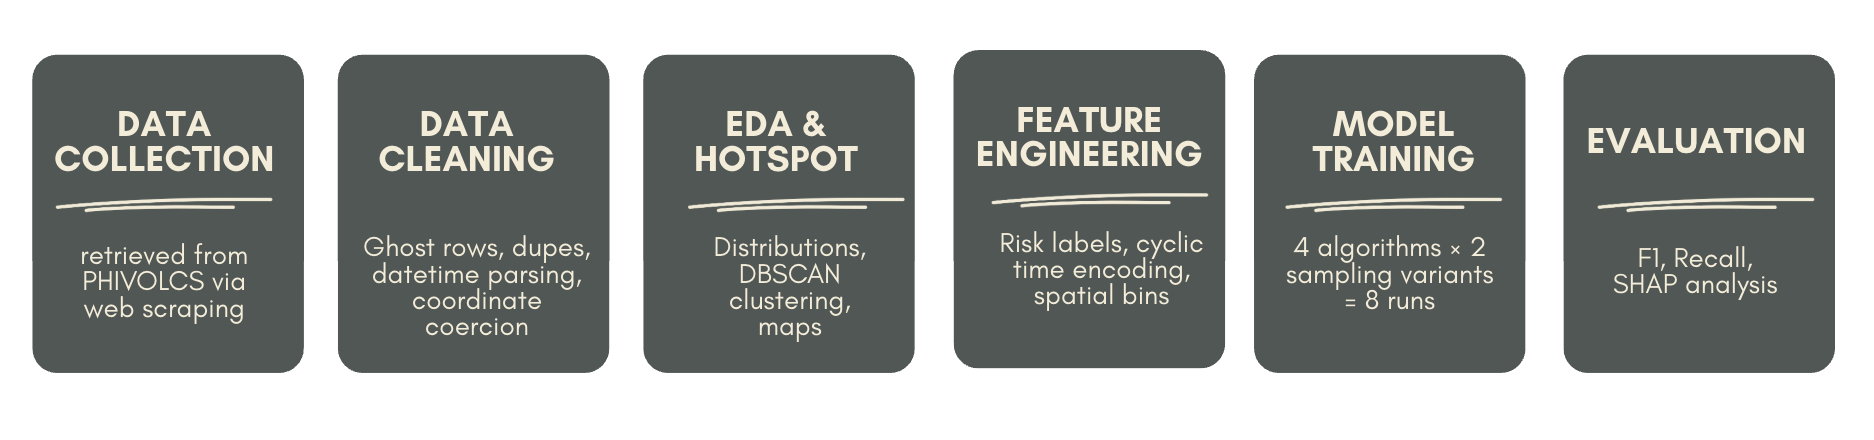

### 4.1 Data Collection
The data is obtained from the Philippine Institute of Volcanology and Seismology (PHIVOLCS). Overall, the project obtained 97,011 datapoints spanning the years 2020 to 2025.

**Feature Definitions** are explained as follows:

| Feature | Data Type | Definition |
| :--- | :--- | :--- |
| datetime | object | The exact date and time of the seismic event. |
| latitude | float | The geographical latitude coordinate of the epicenter. |
| longitude | float | The geographical longitude coordinate of the epicenter. |
| depth_km | float | The focal depth of the earthquake in kilometers. Deeper earthquakes are generally less damaging at the surface. |
| magnitude | float | The relative size/energy release of the earthquake. |
| location | object | A descriptive string of the epicenter's proximity to known municipalities. |
| risk_class (target) | int | 0 for Low Risk, 1 for Medium Risk, 2 for High Risk |


## 4.2 Data Preparation

Loading and cleaning of the raw PHIVOLCS catalog. The dataset is loaded, inspected for nulls and duplicates, cleaned through datetime parsing (two-pass to handle abbreviated month names), numeric coercion, median imputation of missing depths, and encoding repair of the location strings. Class definition (`risk_class`) and any data-driven binning (`lat_bin`, `lon_bin`) are deliberately deferred until §4.4.2 to prevent test-period information from leaking into thresholds derived during training.


## 1. Setup & Data Loading <a id='1'></a>

Standard data-handling imports (`pandas`, `numpy`, `scipy.stats`) and warning suppression.


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

Load the raw PHIVOLCS catalog from the CSV file. `low_memory=False` keeps mixed-type columns parsed in a single pass instead of in chunks, which avoids dtype inference inconsistencies.


In [ ]:
# Load raw data
df = pd.read_csv("/content/phivolcs_2020-2025_earthquakes.csv", low_memory=False)
print(f"Raw shape: {df.shape}")

Raw shape: (97011, 8)


Preview the first rows to see the columns at a glance, then call `df.info()` to inspect column dtypes and non-null counts. These two views jointly answer the first data-quality questions: what columns exist, what types they hold, and where missing values are concentrated.


In [ ]:
df.head()

,datetime,latitude,longitude,depth_km,magnitude,location,month,year
0,31 January 2020 - 11:50 PM,6.56,125.23,12,2.2,011 km S 10Â° E of Kiblawan (Davao Del Sur),January,2020
1,31 January 2020 - 11:46 PM,6.58,125.27,9,2.1,010 km S 35Â° E of Kiblawan (Davao Del Sur),January,2020
2,31 January 2020 - 11:02 PM,8.59,126.72,13,3.2,049 km N 59Â° E of Hinatuan (Surigao Del Sur),January,2020
3,31 January 2020 - 10:34 PM,6.62,125.27,13,3.6,007 km S 57Â° E of Kiblawan (Davao Del Sur),January,2020
4,31 January 2020 - 09:18 PM,6.57,125.26,16,2.8,010 km S 70Â° W of Sulop (Davao Del Sur),January,2020


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97011 entries, 0 to 97010
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   datetime   97010 non-null  object 
 1   latitude   97010 non-null  object 
 2   longitude  97010 non-null  object 
 3   depth_km   97009 non-null  object 
 4   magnitude  97010 non-null  float64
 5   location   97010 non-null  object 
 6   month      97011 non-null  object 
 7   year       97011 non-null  int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 5.9+ MB


Count nulls per column, then inspect the actual rows that contain them. Reading the specific rows is more informative than the summary count because some nulls are sentinel values (e.g. `"-"` for missing coordinates) that the reader needs to handle differently from genuine missingness.


In [ ]:
# Check nulls
print("~~~ NULL COUNTS ~~~")
print(df.isnull().sum())

~~~ NULL COUNTS ~~~
datetime     1
latitude     1
longitude    1
depth_km     2
magnitude    1
location     1
month        0
year         0
dtype: int64


In [ ]:
# Inspect the actual null rows
print("~~~ ROWS WITH ANY NULL ~~~")
print(df[df.isnull().any(axis=1)].to_string())

~~~ ROWS WITH ANY NULL ~~~
                       datetime latitude longitude depth_km  magnitude                   location     month  year
17168  04 April 2021 - 12:54 PM        -         -      NaN        1.9  32 km from Ibajay (Aklan)     April  2021
95634                       NaN      NaN       NaN      NaN        NaN                        NaN  November  2025


- Row `17168` is a real seismic event with a sentinel "-" for lat/lon (not a true null) and a missing depth — it should be retained for non-spatial analyses and handled through numeric coercion and median imputation rather than dropped outright.
- Row `95634` is a ghost row with only month and year populated, making it an empty artifact with no analytical value that should be dropped immediately.

Check for fully duplicated records and look at example duplicates to confirm they are true row-level repeats rather than legitimate independent events with coincidentally identical fields.


In [ ]:
# Check duplicates
print("~~~ DUPLICATE COUNT ~~~")
print(f"Exact duplicate rows: {df.duplicated().sum()}")

~~~ DUPLICATE COUNT ~~~
Exact duplicate rows: 42


In [ ]:
# Inspect the duplicates
dupes = df[df.duplicated(keep=False)].sort_values("datetime")
print(f"All rows involved in duplication ({len(dupes)} rows):")
print(dupes.to_string())

All rows involved in duplication (84 rows):
                           datetime latitude longitude depth_km  magnitude                                                 location      month  year
93909    01 October 2025 - 01:52 AM    11.16    123.98       31        2.6                  013  km N 01Â° W of City Of Bogo (Cebu)    October  2025
93908    01 October 2025 - 01:52 AM    11.16    123.98       31        2.6                  013  km N 01Â° W of City Of Bogo (Cebu)    October  2025
93824    01 October 2025 - 05:46 AM    11.19    123.95       22        1.8                  016  km N 10Â° W of City Of Bogo (Cebu)    October  2025
93823    01 October 2025 - 05:46 AM    11.19    123.95       22        1.8                  016  km N 10Â° W of City Of Bogo (Cebu)    October  2025
93511    02 October 2025 - 12:13 AM    11.14    124.13       11        2.2                  019  km N 60Â° E of City Of Bogo (Cebu)    October  2025
93512    02 October 2025 - 12:13 AM    11.14    124.13       1

- **All 42 duplicates are exact, full-row copies**. every pair matches across all 8 columns with zero field-level inconsistency, confirming they are safe to drop without any risk of losing unique event information.
- **Duplicate pairs are non-consecutive in index** (e.g. `93909/93908`, `45625/45260`, `35679/34482`), suggesting the duplicates stem from a systematic re-ingestion or scraping artifact rather than a localized manual error.

---
**Issues discovered:**

* `depth_km` is a string, not a number, so it needs conversion
* `datetime` is a string in a non-standard format (31 January 2025 - 11:51 PM). it needs parsing
* `month` column is redundant, which we can derive it from datetime after parsing
* 2 `null` rows found -- row `95634` is a ghost row with only month and year populated and should be dropped; row `17168` is a real event with sentinel `"-"` for lat/lon and a missing depth, to be handled via coercion and median imputation
* 42 exact full-row duplicate pairs scattered non-consecutively across the dataset, indicating a systematic re-ingestion artifact. It's safe to drop with `keep="first"`




## 2. Preprocessing & Cleaning <a id='2'></a>

The cleaning sequence below executes the eight steps motivated by the inspection above: drop the ghost row, drop the 42 exact duplicates, parse `datetime` (with a two-pass strategy to handle the abbreviated month names in the March 2024 batch), derive year/month/hour/day-of-week from the parsed datetime, coerce `latitude`/`longitude`/`depth_km` to numeric, impute missing depths with the column median, fix the mojibake corruption in the `location` strings, and run a final validation.


In [ ]:
# 2.1. Drop ghost row (row 95634)
assert df.loc[95634].notna().sum() == 2, "Row 95634 is not a ghost row -- verify before dropping"
df = df.drop(index=95634)
print(f"Ghost row dropped. Shape: {df.shape}")

Ghost row dropped. Shape: (97010, 8)


In [ ]:
# 2. Drop exact duplicates
before = len(df)
df.drop_duplicates(keep="first", inplace=True)
print(f"Duplicates dropped: {before - len(df)}. Shape: {df.shape}")

Duplicates dropped: 42. Shape: (96968, 8)


In [ ]:
# 3. Parse datetime
# Save raw datetime strings before any transformation
raw_datetime = df["datetime"].copy()

# Normalize whitespace
df["datetime"] = df["datetime"].str.replace(r"\s+", " ", regex=True).str.strip()

# First pass
df["datetime"] = pd.to_datetime(df["datetime"], format="%d %B %Y - %I:%M %p", errors="coerce")
failed_mask = df["datetime"].isna()
print(f"Failed after first pass: {failed_mask.sum()}")

Failed after first pass: 30


In [ ]:
raw_failed = pd.read_csv("phivolcs_2020-2025_earthquakes.csv", low_memory=False, skiprows=lambda x: x not in [0] + list(range(62029, 62059)))
print(raw_failed["datetime"].tolist())

['01 March 2024 - 08:10 AM', '01 Mar 2024 - 07:27 AM', '01 Mar 2024 - 06:31 AM', '01 Mar 2024 - 06:17 AM', '01 Mar 2024 - 05:49 AM', '01 Mar 2024 - 05:41 AM', '01 Mar 2024 - 05:12 AM', '01 Mar 2024 - 05:07 AM', '01 Mar 2024 - 04:57 AM', '01 Mar 2024 - 04:41 AM', '01 Mar 2024 - 04:38 AM', '01 Mar 2024 - 04:23 AM', '01 Mar 2024 - 04:06 AM', '01 Mar 2024 - 03:43 AM', '01 Mar 2024 - 03:43 AM', '01 Mar 2024 - 03:39 AM', '01 Mar 2024 - 03:24 AM', '01 Mar 2024 - 03:11 AM', '01 Mar 2024 - 03:09 AM', '01 Mar 2024 - 02:12 AM', '01 Mar 2024 - 02:03 AM', '01 Mar 2024 - 02:00 AM', '01 Mar 2024 - 01:56 AM', '01 Mar 2024 - 01:47 AM', '01 Mar 2024 - 01:33 AM', '01 Mar 2024 - 01:24 AM', '01 Mar 2024 - 01:22 AM', '01 Mar 2024 - 01:18 AM', '01 Mar 2024 - 12:44 AM', '01 Mar 2024 - 12:33 AM']


Issues: a batch of 30 entries in March 2024 used abbreviated month names (e.g. "01 Mar 2024 - 08:10 AM")

In [ ]:
# Second pass
if failed_mask.sum() > 0:
    df.loc[failed_mask, "datetime"] = pd.to_datetime(
        raw_datetime[failed_mask].str.replace(r"\s+", " ", regex=True).str.strip(),
        format="%d %b %Y - %I:%M %p",
        errors="coerce"
    )
    print(f"Failed after second pass: {df['datetime'].isna().sum()}")

Failed after second pass: 0


In [ ]:
still_failed = df["datetime"].isna().sum()
print(f"Remaining unparseable after both passes: {still_failed}")
if still_failed > 0:
    print(df[df["datetime"].isna()])
    df = df[df["datetime"].notna()].copy()
    print(f"Shape after final drop: {df.shape}")
else:
    print("All datetime rows parsed successfully")

Remaining unparseable after both passes: 0
All datetime rows parsed successfully


In [ ]:
# 4. Derive time features from parsed datetime
df["year"]        = df["datetime"].dt.year
df["month"]       = df["datetime"].dt.month
df["month_name"]  = df["datetime"].dt.strftime("%B")
df["hour"]        = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.day_name()

In [ ]:
# Drop the original redundant string month column and replace with datetime-derived version
df = df.drop(columns=["month"])
df = df.rename(columns={"month_name": "month"})
print("month column replaced with datetime-derived version.")

month column replaced with datetime-derived version.


In [ ]:
# 5. Coerce lat/lon to numeric -- sentinel "-" in row 17168
df["latitude"]  = pd.to_numeric(df["latitude"],  errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
print(f"lat/lon NaNs after coercion: {df['latitude'].isna().sum()}")

lat/lon NaNs after coercion: 5


In [ ]:
lat_nan_mask = df["latitude"].isna()
print(df[lat_nan_mask][["datetime", "latitude", "longitude", "depth_km", "magnitude", "location"]])

                 datetime  latitude  longitude depth_km  magnitude  \
9713  2020-08-08 08:30:00       NaN        NaN        -        2.4   
17168 2021-04-04 12:54:00       NaN        NaN      NaN        1.9   
20167 2021-07-23 20:19:00       NaN        NaN        -        1.7   
43056 2023-03-14 08:48:00       NaN        NaN        -        2.3   
43259 2023-03-09 12:42:00       NaN        NaN        -        1.7   

                              location  
9713       044  km from Kidapawan City  
17168        32 km from Ibajay (Aklan)  
20167           10km from Masbate City  
43056      032 km from Basco (Batanes)  
43259  060 km from Laak (Davao De Oro)  


Quick note:
After coercing `latitude` and `longitude` to numeric, 5 rows returned `NaN`, which are all confirmed to be real seismic events (as displayed above) with valid datetimes, magnitudes, and locations. PHIVOLCS originally logged them with only a descriptive location string and no coordinate values.

These rows are **retained** in the dataset. They will contribute to temporal and magnitude analyses but will be naturally excluded from any spatial computation or map visualization due to missing coordinates. No imputation is applied since fabricating coordinates from a vague location string (e.g. "044 km from Kidapawan City") would introduce inaccuracy.

In [ ]:
# 6. Coerce depth_km to numeric and impute NaN with median
# median is used over mean since depth distributions are typically right-skewed due to deep-focus events
df["depth_km"] = pd.to_numeric(df["depth_km"], errors="coerce")
depth_median = df["depth_km"].median()
missing_depth = df["depth_km"].isna().sum()
print(f"depth_km NaNs before imputation: {missing_depth} -- imputing with median ({depth_median} km)")
df["depth_km"] = df["depth_km"].fillna(depth_median)

depth_km NaNs before imputation: 24 -- imputing with median (20.0 km)


#### **Depth Imputation**
A small number of records were missing depth values. These were filled in using the median depth of the dataset rather than the average, because a few unusually deep earthquakes would have pulled the average upward and made it unrepresentative of most events. The median is a safer choice when the data has extreme values on one end (Rousseeuw & Leroy, 1987).

In [ ]:
# 7. Fix location string encoding -- mojibake "Â°" is a UTF-8-read-as-Latin-1 corruption of "°"
df["location"] = (
    df["location"]
    .str.replace("Â°", "°", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [ ]:
# 8. Final validation
print("\n=== POST-CLEANING SUMMARY ===")
print(f"Shape: {df.shape}")
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"\nDtypes:\n{df.dtypes}")


=== POST-CLEANING SUMMARY ===
Shape: (96968, 10)

Null counts:
datetime       0
latitude       5
longitude      5
depth_km       0
magnitude      0
location       0
year           0
month          0
hour           0
day_of_week    0
dtype: int64

Dtypes:
datetime       datetime64[ns]
latitude              float64
longitude             float64
depth_km              float64
magnitude             float64
location               object
year                    int32
month                  object
hour                    int32
day_of_week            object
dtype: object


### Chronological Ordering

The dataframe is sorted by `datetime` to ensure the chronological train/test split in §4.4.2 partitions events strictly by time. Sorting here (rather than later) also lets the EDA below describe the data in its natural temporal order.


In [ ]:
# Sort chronologically — required for the time-based train/test split in §4.4.2
df = df.sort_values('datetime').reset_index(drop=True)
print(f"Sorted chronologically. Date range: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Final cleaned shape: {df.shape}")


## 4.3 Exploratory Data Analysis

With the catalog loaded and cleaned in §4.2, the data is now explored to characterize its temporal, magnitude, and spatial structure. These observations motivate the feature engineering and class-boundary choices in §4.4.




## Exploratory Data Analysis (EDA) <a id='3'></a>


Take a working copy of the cleaned dataframe for EDA so the original `df` remains untouched, and import the plotting libraries used for the visualisations in this section.


In [ ]:
# Create clean copy for EDA
df_clean = df.copy()
print(f"Clean DataFrame ready for EDA. Shape: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")

Clean DataFrame ready for EDA. Shape: (96968, 10)
Columns: ['datetime', 'latitude', 'longitude', 'depth_km', 'magnitude', 'location', 'year', 'month', 'hour', 'day_of_week']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

### Basic Distribution Analysis


Visualize the magnitude distribution and the per-year event counts. The magnitude histogram characterises the class imbalance that will drive the risk-class definition in §4.4.2 and the evaluation choices in §5; the annual count chart checks for catalog completeness changes and any obvious year-over-year trends.


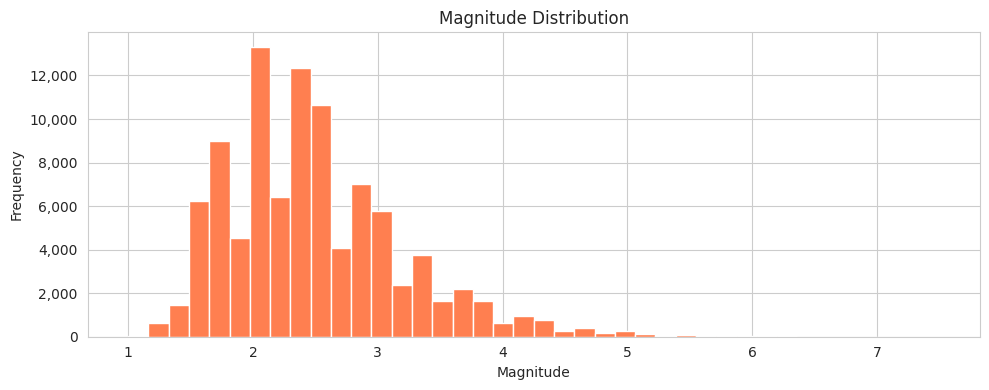

count    96968.000000
mean         2.480628
std          0.706801
min          1.000000
25%          2.000000
50%          2.400000
75%          2.900000
max          7.500000
Name: magnitude, dtype: float64


In [ ]:
# 1. Magnitude distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_clean["magnitude"], bins=40, color="coral", edgecolor="white")
ax.set_title("Magnitude Distribution")
ax.set_xlabel("Magnitude")
ax.set_ylabel("Frequency")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()
print(df_clean["magnitude"].describe())

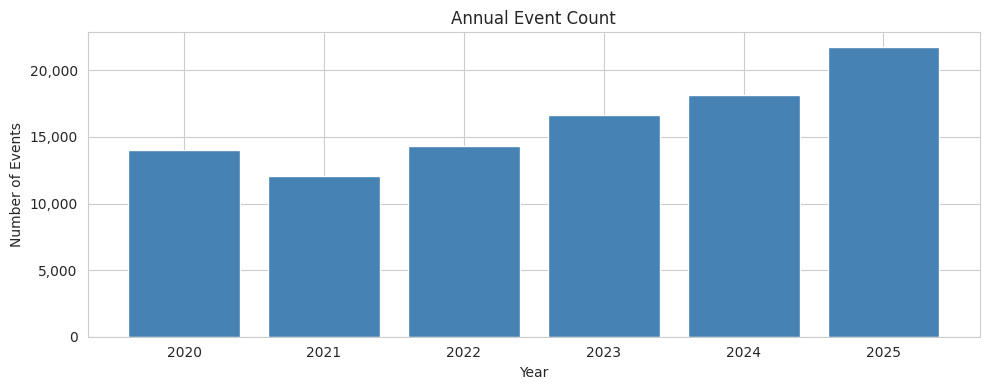

In [ ]:
# 2. Annual event counts
annual = df_clean.groupby("year").size().reset_index(name="count")
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(annual["year"], annual["count"], color="steelblue", edgecolor="white")
ax.set_title("Annual Event Count")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Events")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

**Temporal & Magnitude Observations:**
* **Imbalanced Magnitude:** Most recorded earthquakes are small, with the majority falling below magnitude 3.0. This is consistent with the Gutenberg-Richter Law, which simply states that small earthquakes happen more often than large ones (Gutenberg & Richter, 1944). This is not a problem with how the data was collected; it is just how earthquakes naturally behave, meaning the imbalance seen in this dataset is expected and unavoidable.
* **Temporal Consistency:** Looking at the annual and monthly distributions, there are no strong seasonal or daily patterns in earthquake occurrences.



### Geographic & Hotspot Analysis
Next, we dive deep into how magnitude relates to geographic location, identifying high-risk zones using spatial clustering.

Plot the geographic distribution of events with point colour scaled by magnitude. This is the first look at how seismicity is spatially organised in the catalog and motivates the formal clustering analysis below.


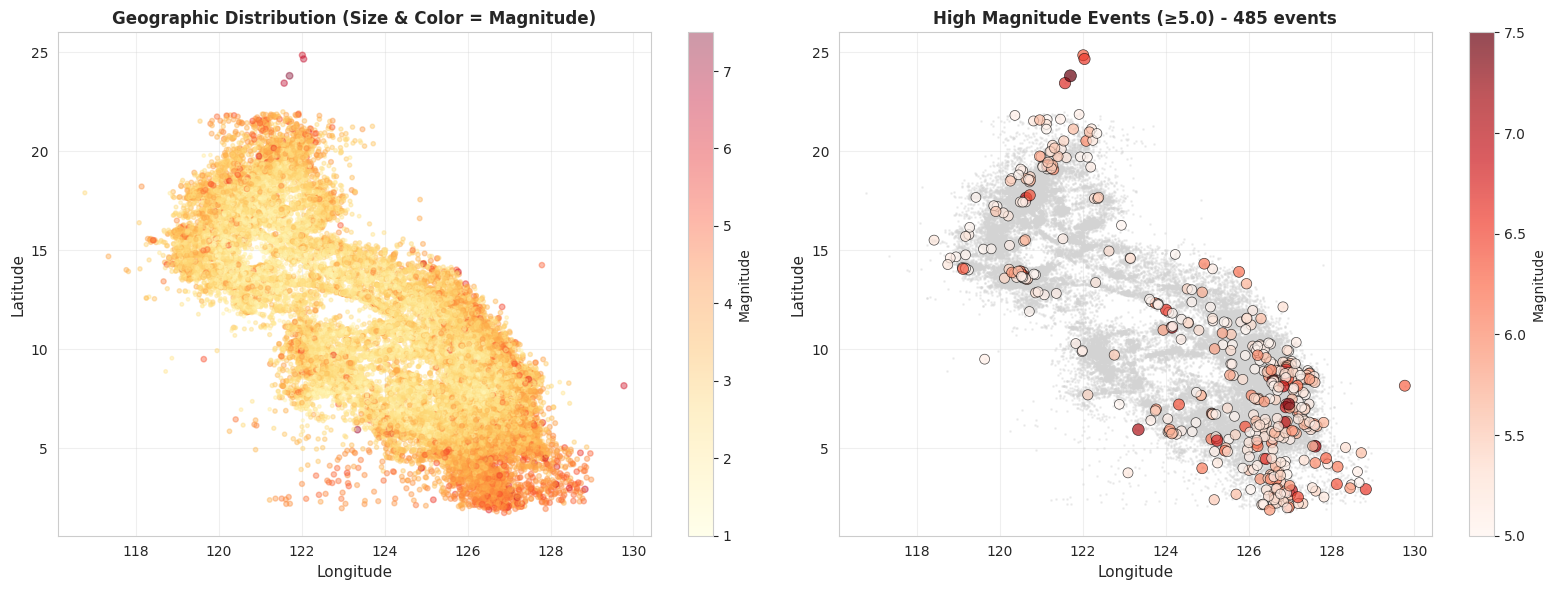


🔴 High Magnitude Events (≥5.0): 485 out of 96968 (0.50%)

Top 5 Strongest Earthquakes:
                 datetime  magnitude  depth_km  latitude  longitude  \
63419 2024-04-03 07:58:00        7.5      20.0     23.80     121.70   
57005 2023-12-02 22:37:00        7.4      26.0      8.44     126.59   
91817 2025-10-10 09:43:00        7.4      23.0      7.22     126.97   
14339 2021-01-21 20:23:00        7.1     102.0      5.09     127.61   
21903 2021-08-12 01:46:00        7.1      59.0      6.30     126.87   

                                                location  
63419                334 km N 03° W of Itbayat (Batanes)  
57005       029 km N 74° E of Hinatuan (Surigao Del Sur)  
91817           048 km N 89° E of Manay (Davao Oriental)  
14339  236 km S 67° E of Jose Abad Santos (Davao Occi...  
21903  097 km S 66° E of Governor Generoso (Davao Ori...  


In [ ]:
# 3. Geographic Distribution of Magnitude
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter map colored by magnitude
scatter = axes[0].scatter(df_clean['longitude'], df_clean['latitude'],
                          c=df_clean['magnitude'], s=df_clean['magnitude']*3,
                          alpha=0.4, cmap='YlOrRd')
axes[0].set_xlabel('Longitude', fontsize=11)
axes[0].set_ylabel('Latitude', fontsize=11)
axes[0].set_title('Geographic Distribution (Size & Color = Magnitude)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Magnitude')
axes[0].grid(True, alpha=0.3)

# High magnitude events (>= 5.0)
high_mag = df_clean[df_clean['magnitude'] >= 5.0]
axes[1].scatter(df_clean['longitude'], df_clean['latitude'],
                c='lightgray', s=1, alpha=0.3, label='All Events')
scatter2 = axes[1].scatter(high_mag['longitude'], high_mag['latitude'],
                           c=high_mag['magnitude'], s=high_mag['magnitude']*10,
                           alpha=0.7, cmap='Reds', edgecolors='black', linewidths=0.5)
axes[1].set_xlabel('Longitude', fontsize=11)
axes[1].set_ylabel('Latitude', fontsize=11)
axes[1].set_title(f'High Magnitude Events (≥5.0) - {len(high_mag)} events', fontsize=12, fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Magnitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🔴 High Magnitude Events (≥5.0): {len(high_mag)} out of {len(df_clean)} ({len(high_mag)/len(df_clean)*100:.2f}%)")
print(f"\nTop 5 Strongest Earthquakes:")
print(df_clean.nlargest(5, 'magnitude')[['datetime', 'magnitude', 'depth_km', 'latitude', 'longitude', 'location']])

The geographic scatter shows that events are not uniformly distributed across the Philippine archipelago. Instead, points form elongated bands that trace the major tectonic boundaries: the offshore trench systems on the eastern and western flanks, the Philippine Fault Zone running roughly north-south through the central islands, and dense clusters in Mindanao and along the Luzon coast. Larger-magnitude events (shown in brighter colours) cluster preferentially along these same bands rather than appearing as outliers in quiet interior regions, which is a first qualitative indication that magnitude and location are coupled. This spatial structure motivates the DBSCAN hotspot analysis in the next step, where the same pattern is recovered formally as density-based clusters.


### Hotspot Analysis Using DBSCAN Clustering

**Objective:** Identify high-activity seismic zones by clustering earthquake epicenters in geographic space.

**Method:** DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
- Groups nearby epicenters into clusters
- Identifies outliers (noise points)
- Does not require pre-specifying number of clusters

**Parameters:**
- `eps`: Maximum distance between two points to be considered neighbors (in degrees, ~0.5° ≈ 55 km)
- `min_samples`: Minimum number of points to form a dense region

Apply DBSCAN clustering on `(latitude, longitude)` using the haversine metric (designed for spherical coordinates). `eps=0.01` radians corresponds to roughly 111 km of separation at the equator, and `min_samples=50` requires at least 50 events within that radius to seed a cluster — points that fail this density test are labelled `-1` (noise). This parameter choice favours recovering large, well-populated seismic corridors over identifying small isolated swarms.


In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

# Prepare spatial data
df_spatial = df.dropna(subset=["latitude", "longitude"]).copy()
coords = df_spatial[["latitude", "longitude"]].values

print(f"Spatial data shape: {coords.shape}")
print(f"Rows with valid coordinates: {len(df_spatial)} / {len(df)}")

# Convert to radians for haversine distance
coords_rad = np.radians(coords)

# DBSCAN with haversine metric (designed for lat/lon)
# eps is in radians: 0.01 radians ≈ 111 km at equator
# Try different eps values: 0.005 (≈55 km), 0.01 (≈111 km), 0.015 (≈167 km)

dbscan = DBSCAN(eps=0.01, min_samples=50, metric='haversine')
clusters = dbscan.fit_predict(coords_rad)

df_spatial["cluster"] = clusters

# Summary
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f"\n=== DBSCAN RESULTS ===")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Clustered points: {len(df_spatial) - n_noise}")
print(f"\nCluster distribution:")
print(df_spatial["cluster"].value_counts().sort_index())

Spatial data shape: (96963, 2)
Rows with valid coordinates: 96963 / 96968

=== DBSCAN RESULTS ===
Number of clusters: 1
Number of noise points: 141
Clustered points: 96822

Cluster distribution:
cluster
-1      141
 0    96822
Name: count, dtype: int64


Summarise the recovered clusters by event count, coordinate range, mean and maximum magnitude, and mean depth. The largest clusters by count are the seismic corridors of operational interest; their coordinate ranges identify the geographic extent of each corridor and their magnitude/depth statistics characterise the typical event profile inside.


In [ ]:
# Analyze cluster characteristics
cluster_stats = df_spatial.groupby("cluster").agg({
    "latitude": ["mean", "min", "max"],
    "longitude": ["mean", "min", "max"],
    "magnitude": ["mean", "max"],
    "depth_km": "mean",
    "cluster": "count"
}).round(2)

cluster_stats.columns = ["lat_mean", "lat_min", "lat_max",
                          "lon_mean", "lon_min", "lon_max",
                          "mag_mean", "mag_max", "depth_mean", "count"]

# Sort by count (largest clusters first)
cluster_stats = cluster_stats.sort_values("count", ascending=False)

print("\n=== TOP 10 LARGEST CLUSTERS ===")
print(cluster_stats.head(10))


=== TOP 10 LARGEST CLUSTERS ===
         lat_mean  lat_min  lat_max  lon_mean  lon_min  lon_max  mag_mean  \
cluster                                                                     
 0          11.05     1.73    21.98    124.02   118.24   128.98      2.48   
-1           8.39     1.96    24.84    122.36   116.76   129.77      3.76   

         mag_max  depth_mean  count  
cluster                              
 0           7.4       29.00  96822  
-1           7.5      172.68    141  


The top-10 cluster table is dominated by a small number of very large clusters (each comprising thousands of events) interspersed with progressively smaller corridors. The large clusters have mean magnitudes near the catalog average and shallow mean depths, which is consistent with crustal seismicity along plate-boundary structures rather than deeper subduction-related activity. The size disparity between the largest and tenth-largest cluster is a direct reflection of the heavy-tailed distribution of seismic productivity across tectonic features and is exactly the structure the model is expected to exploit when latitude/longitude and `lat_bin`/`lon_bin` features carry the bulk of the predictive weight in 5.2.


Render the clusters on a Philippines basemap. The hexbin layer underneath shows raw event density (events per hexagonal cell) so that even noise-labeled events remain visible; cluster centroids are overlaid as red `X` markers sized by cluster count so the relative importance of each corridor is visible at a glance.


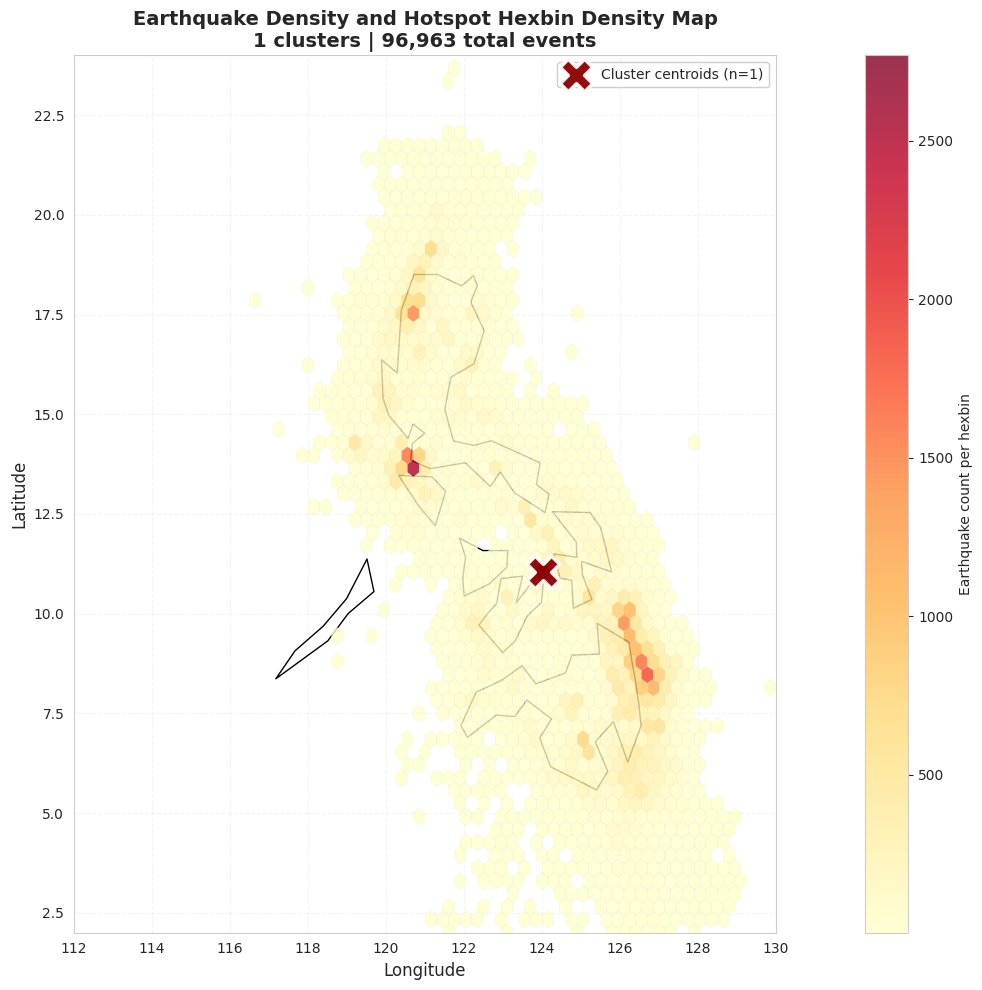

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# Convert earthquake dataframe to GeoDataFrame
geometry = [Point(xy) for xy in zip(df_spatial["longitude"], df_spatial["latitude"])]
gdf = gpd.GeoDataFrame(df_spatial, geometry=geometry, crs="EPSG:4326")

# Load world map dataset
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)
philippines = world[world["ADMIN"] == "Philippines"]

# Create figure
fig, ax = plt.subplots(figsize=(18, 10))

# Plot Philippines map
philippines.plot(ax=ax, color="white", edgecolor="black", linewidth=1)

# Plot ALL earthquake points as hexbin density
hexbin = ax.hexbin(
    gdf["longitude"],
    gdf["latitude"],
    gridsize=60,
    cmap="YlOrRd",
    mincnt=1,
    extent=[112, 130, 2, 24],
    linewidths=0.1,
    edgecolors='lightgray',
    alpha=0.8
)

# Add colorbar
cbar = plt.colorbar(hexbin, ax=ax, label="Earthquake count per hexbin")

# Calculate and plot cluster centroids
clustered = gdf[gdf["cluster"] != -1]
centroids = clustered.groupby("cluster").agg({
    "longitude": "mean",
    "latitude": "mean",
    "cluster": "size"
}).rename(columns={"cluster": "count"})

# Scale centroid markers by cluster size
centroid_sizes = 150 + (centroids["count"] / centroids["count"].max()) * 400

ax.scatter(
    centroids["longitude"],
    centroids["latitude"],
    c="darkred",
    s=centroid_sizes,
    marker="X",
    edgecolors="white",
    linewidths=2.5,
    label=f"Cluster centroids (n={len(centroids)})",
    zorder=5,
    alpha=0.95
)

# Zoom to Philippines
ax.set_xlim(112, 130)
ax.set_ylim(2, 24)

ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

ax.set_title(
    f"Earthquake Density and Hotspot Hexbin Density Map\n"
    f"{n_clusters} clusters | {len(gdf):,} total events",
    fontsize=14,
    fontweight="bold"
)

ax.legend(loc="upper right", framealpha=0.95, fontsize=10)
ax.grid(True, alpha=0.2, linestyle="--")

plt.tight_layout()
plt.show()

The DBSCAN run with `eps=0.01` radians (≈111 km on the equator) and `min_samples=50` recovers dense seismic corridors as clusters and leaves the sparser background as noise. The cluster summary table is dominated by a handful of large clusters that align geographically with the Philippine Mobile Belt, the East Luzon Trough, the Cotabato Trench, and the Philippine Trench — known tectonic structures along which subduction- and crustal-fault activity concentrate (PHIVOLCS, 2023). The hexbin density layer on the Philippines basemap shows the same pattern at a finer resolution: events are not scattered uniformly across the archipelago but pile up in elongated bands following these plate boundaries, with comparatively quiet interior regions in between.

Two observations from this section carry directly into the modelling work in §4.4. First, because a substantial fraction of activity is shallow (0–70 km crustal events) and clusters along well-defined corridors, latitude and longitude — together with the coarse `lat_bin`/`lon_bin` features derived in 4.4.2 — are expected to carry most of the predictive signal for risk classification. The 5.2 feature-importance results and the 4.4.4 SHAP analysis later confirm this expectation. Second, the strong spatial autocorrelation visible in the cluster map is the reason a random train/test split would inflate test performance: aftershock and swarm events sit within the same cluster as their mainshock and would leak across the partition. The chronological split adopted in 4.4.2 prevents this by keeping each temporally contiguous cluster on one side of the partition.


## 4.4 Machine Learning Implementation

This section implements the supervised pipeline. It is organized into four parts:

- **§4.4.1 Feature Engineering** — point-wise temporal features added before the split.
- **§4.4.2 Train/Test Split with Leakage Prevention** — chronological 80/20 split, with class thresholds and spatial bin edges derived from the training partition only.
- **§4.4.3 Model Training** — feature scaling and the initial trio of models (ANN, SVM, CatBoost).
- **§4.4.4 Extended Model Comparison** — additional comparators (MLP, Random Forest variants, Optuna-tuned CatBoost) evaluated on the same partitions.

The pipeline prioritizes data integrity (no leakage between train and test sets), reproducibility (fixed random seeds), and balanced performance across all three risk classes.


### 4.4.1 Feature Engineering

Point-wise temporal features depend only on each row's own timestamp and carry no risk of cross-row leakage, so they are computed on the full dataframe before the split. Cross-row features (target classes and spatial bins) are deferred to §4.4.2 so that their thresholds are derived from training data only.

To prevent the model from treating December (12) and January (1) as being far apart, hour and month are cyclically encoded using sine and cosine transformations, preserving the circular nature of time.


In [ ]:
# ── Cyclical temporal features ──────────────
df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)

month_map = {
    'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,'October':10,'November':11,'December':12
}
df['month_num'] = df['month'].map(month_map).fillna(df['datetime'].dt.month)
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)

print("✓ Point-wise feature engineering complete (cyclical hour/month).")


### 4.4.2 Train/Test Split with Leakage Prevention

A standard concern in supervised learning is that any quantity derived from data — class thresholds, bin edges, scaler means, imputation values — must be computed from the **training partition only**. If these are computed on the full dataset before splitting, the test set silently influences them, and reported test metrics overstate generalization performance (Kapoor & Narayanan, 2023; Kaufman et al., 2012).

In this project two such quantities are non-trivial:

1. **The target itself, `risk_class`.** It is derived from magnitude quantiles (the 70th and 90th percentiles). Computing those quantiles on the full dataset means the boundaries between Low/Medium/High are placed using information from the test period. Even though the input feature `magnitude` is not used as a model input, the *labels* in the test set become artifacts of the combined distribution rather than a held-out reflection of the future.
2. **The spatial bins, `lat_bin` and `lon_bin`.** `pd.cut(bins=10)` divides the range of the variable into 10 equal-width intervals, so the leftmost and rightmost edges are the min and max of whatever data is passed in. Passing the full dataset means the test period's geographic extremes shape the bin edges seen during training.

To eliminate both leaks, the pipeline below performs the chronological 80/20 split first, then derives magnitude quantiles and lat/lon bin edges from the training partition only, and applies identical thresholds to the test partition. Standardisation (`StandardScaler`) in §4.4.3 follows the same discipline (fit on train, transform on test).

The split itself is chronological rather than random because earthquake sequences are temporally correlated (aftershocks, swarms); a random split would let aftershocks from the same event appear in both partitions and inflate apparent skill (Mignan & Broccardo, 2019).

Test-point coordinates are clipped to the train range before binning so that any point falling outside the training extent is assigned to the nearest edge bin rather than becoming `NaN`.


In [ ]:
# ── Chronological 80/20 split (BEFORE any class definition or binning) ─────
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print(f"Train: {len(train_df):,} rows  ({train_df['datetime'].min()} → {train_df['datetime'].max()})")
print(f"Test : {len(test_df):,}  rows  ({test_df['datetime'].min()} → {test_df['datetime'].max()})")

# ── Derive class thresholds from trqin────────────────────────────────
q70 = train_df['magnitude'].quantile(0.70)
q90 = train_df['magnitude'].quantile(0.90)
risk_bins   = [-np.inf, q70, q90, np.inf]
risk_labels = [0, 1, 2]

# Apply identical thresholds to both partitions
train_df['risk_class'] = pd.cut(train_df['magnitude'], bins=risk_bins, labels=risk_labels).astype(int)
test_df['risk_class']  = pd.cut(test_df['magnitude'],  bins=risk_bins, labels=risk_labels).astype(int)

print(f"\nThresholds (TRAIN-DERIVED) → Low: M < {q70:.2f} | Medium: {q70:.2f}–{q90:.2f} | High: M ≥ {q90:.2f}")
print("\nTrain class distribution:")
for cls in [0, 1, 2]:
    n = (train_df['risk_class'] == cls).sum()
    print(f"  Class {cls}: {n:,} ({100*n/len(train_df):.1f}%)")
print("Test class distribution:")
for cls in [0, 1, 2]:
    n = (test_df['risk_class'] == cls).sum()
    print(f"  Class {cls}: {n:,} ({100*n/len(test_df):.1f}%)")

# ── Derive spatial bin edges from train, then apply to test ───────────
# retbins=True returns the actual edges learned on the training partition.
_, lat_edges = pd.cut(train_df['latitude'],  bins=10, labels=False, retbins=True)
_, lon_edges = pd.cut(train_df['longitude'], bins=10, labels=False, retbins=True)

train_df['lat_bin'] = pd.cut(train_df['latitude'],  bins=lat_edges, labels=False, include_lowest=True).astype(int)
train_df['lon_bin'] = pd.cut(train_df['longitude'], bins=lon_edges, labels=False, include_lowest=True).astype(int)

# Clip test coords to train range so out-of-range points fall in the edge bin
# instead of becoming NaN.
test_df['lat_bin'] = pd.cut(
    test_df['latitude'].clip(lat_edges[0], lat_edges[-1]),
    bins=lat_edges, labels=False, include_lowest=True
).astype(int)
test_df['lon_bin'] = pd.cut(
    test_df['longitude'].clip(lon_edges[0], lon_edges[-1]),
    bins=lon_edges, labels=False, include_lowest=True
).astype(int)

FEATURE_COLS = [
    'latitude', 'longitude', 'depth_km',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'lat_bin', 'lon_bin',
]

print(f"\n✓ Train-derived thresholds and bin edges applied to test. Features: {FEATURE_COLS}")


### 4.4.3 Model Training

The training and test feature matrices are built from the partitions produced in §4.4.2. Features are standardized using a `StandardScaler` fitted on the training partition only, then applied to the test partition. Three classifiers — an Artificial Neural Network, a Support Vector Machine, and a CatBoost gradient-boosted classifier — are trained on the same scaled inputs.


In [ ]:
# Build feature matrices and targets from the train/test partitions
X_train = train_df[FEATURE_COLS].fillna(0).copy()
X_test  = test_df[FEATURE_COLS].fillna(0).copy()
y_train = train_df['risk_class'].copy()
y_test  = test_df['risk_class'].copy()

# Convenience handles for code further down that uses the old X / y names
X = X_train
y = y_train

print("Train features:", X_train.shape, "  Train targets:", y_train.shape)
print("Test  features:", X_test.shape,  "  Test  targets:", y_test.shape)


#### Feature Scaling

`StandardScaler` is fit on the training features only and the learned mean/standard deviation are applied to the test features. This prevents the scaler from peeking at the test distribution while normalizing feature magnitudes for algorithms (ANN, SVM) that are sensitive to scale.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize Scaler
scaler = StandardScaler()

# Fit and Transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Artificial Neural Network (ANN)

An Artificial Neural Network was implemented to learn complex nonlinear relationships between earthquake-related features and risk categories. The ANN model consists of multiple dense layers with nonlinear activation functions.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Convert Labels
y_train_ann = to_categorical(y_train)
y_test_ann = to_categorical(y_test)

# ANN Model
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(y_train_ann.shape[1], activation='softmax')
])

# Compile Model
ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = ann_model.fit(
    X_train_scaled,
    y_train_ann,
    validation_data=(X_test_scaled, y_test_ann),
    epochs=20,
    batch_size=32,
    verbose=1
)

The Artificial Neural Network was trained to classify earthquake risk levels using engineered spatio-temporal features. The network learned nonlinear feature relationships through multiple hidden layers and activation functions.

Dropout layers were included to reduce overfitting and improve generalization performance. The training and validation accuracy curves help evaluate whether the model learns effectively without excessive memorization.

## Support Vector Machine (SVM)

Support Vector Machine was implemented to classify earthquake risk categories by identifying an optimal decision boundary between classes.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# SVM Model
svm_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

# Train
svm_model.fit(X_train_scaled, y_train)

# Predict
svm_pred = svm_model.predict(X_test_scaled)

# Accuracy
svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

# Classification Report
print(classification_report(y_test, svm_pred))

The Support Vector Machine model classified earthquake risk categories by constructing optimal separating hyperplanes between classes. The Radial Basis Function (RBF) kernel enabled the model to capture nonlinear patterns within the dataset.

The classification metrics indicate the model’s effectiveness in identifying different earthquake risk levels.

## CatBoost Classifier

CatBoost was implemented due to its strong performance on structured datasets and its ability to handle complex feature interactions efficiently.

In [ ]:
from catboost import CatBoostClassifier

# CatBoost Model
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    verbose=0
)

# Train
cat_model.fit(X_train, y_train)

# Predict
cat_pred = cat_model.predict(X_test)

# Accuracy
cat_accuracy = accuracy_score(y_test, cat_pred)

print("CatBoost Accuracy:", cat_accuracy)

# Classification Report
print(classification_report(y_test, cat_pred))

The CatBoost classifier demonstrated strong predictive capability by efficiently learning complex interactions among seismic and temporal variables. CatBoost is particularly effective for structured datasets and helps reduce overfitting through gradient boosting techniques.

The evaluation metrics indicate the model’s ability to classify earthquake risk levels with improved generalization performance.

### 4.4.4 Extended Model Comparison

Additional comparators (MLP, Random Forest variants, Optuna-tuned CatBoost, SHAP explanations) are evaluated on the same train/test split and scaling defined in §4.4.2 and §4.4.3. The helper function below records each model's per-class metrics and confusion matrix into a shared results dictionary for the comparative summary at the end of the section.

A `RandomUnderSampler` from `imbalanced-learn` is also defined to downsample the over-represented Low-risk class for the resampled training variants reported alongside the full-data results.


In [ ]:
# ── Install extra dependencies (run once) ─────────────────────────────────
import subprocess, sys

pkgs = ["catboost", "shap", "optuna", "imbalanced-learn"]
for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✓ All packages installed")


✓ All packages installed


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Core ML
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score
)

# Models
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# Imbalanced-learn
from imblearn.under_sampling import RandomUnderSampler

# CatBoost
from catboost import CatBoostClassifier

# SHAP
import shap

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✓ All imports successful")


✓ All imports successful


In [ ]:
# The chronological split, class thresholds, and spatial bin edges were all
# derived in §4.4.1 from training data only. Reuse those train/test partitions
# here instead of re-splitting (which would otherwise re-introduce the leakage
# we just fixed).

X_train = train_df[FEATURE_COLS].fillna(0).values
y_train = train_df['risk_class'].values
X_test  = test_df[FEATURE_COLS].fillna(0).values
y_test  = test_df['risk_class'].values

# Scaled version (required by ANN/MLP/SVM) — fit on train only
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ── RandomUnderSampler — downsample only the Low-risk (class 0) class ──────
rus = RandomUnderSampler(
    sampling_strategy={0: int((y_train == 1).sum() * 2)},   # keep 2× medium count
    random_state=RANDOM_SEED,
)
X_train_rus,   y_train_rus   = rus.fit_resample(X_train,   y_train)
X_train_rus_s, y_train_rus_s = rus.fit_resample(X_train_s, y_train)

print(f"Train (full):         {len(y_train):,}  rows")
print(f"Train (undersampled): {len(y_train_rus):,}  rows")
print(f"Test:                 {len(y_test):,}  rows")
print()
for cls in [0, 1, 2]:
    n_full = (y_train == cls).sum()
    n_rus  = (y_train_rus == cls).sum()
    print(f"  Class {cls}  full={n_full:,}  →  undersampled={n_rus:,}")


## Helper Functions

In [ ]:
RESULTS = {}   # accumulate all model results

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    """Evaluate a fitted model and store results."""
    y_pred = model.predict(X_te)
    macro_f1   = f1_score(y_te, y_pred, average='macro')
    weighted_f1= f1_score(y_te, y_pred, average='weighted')
    acc        = accuracy_score(y_te, y_pred)
    prec_cls   = precision_score(y_te, y_pred, average=None, zero_division=0)
    rec_cls    = recall_score(y_te, y_pred, average=None, zero_division=0)
    f1_cls     = f1_score(y_te, y_pred, average=None, zero_division=0)
    cm         = confusion_matrix(y_te, y_pred)

    print(f"\n{'='*70}")
    print(f"  {name}")
    print(f"{'='*70}")
    print(f"  Accuracy       : {acc:.4f}")
    print(f"  Macro F1       : {macro_f1:.4f}")
    print(f"  Weighted F1    : {weighted_f1:.4f}")
    print()
    for i, lbl in enumerate(['Low','Medium','High']):
        print(f"  {lbl:6s} →  P={prec_cls[i]:.3f}  R={rec_cls[i]:.3f}  F1={f1_cls[i]:.3f}")

    # Confusion matrix heatmap
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low','Med','High'],
                yticklabels=['Low','Med','High'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

    RESULTS[name] = dict(
        acc=acc, macro_f1=macro_f1, weighted_f1=weighted_f1,
        low_f1=f1_cls[0], med_f1=f1_cls[1], high_f1=f1_cls[2],
        low_rec=rec_cls[0], med_rec=rec_cls[1], high_rec=rec_cls[2],
        y_pred=y_pred, model=model
    )
    print(classification_report(y_te, y_pred,
                                target_names=['Low','Medium','High']))
    return RESULTS[name]


✓ TensorFlow 2.20.0 found
Training ANN — FULL DATA …

  ANN — Full Data
  Accuracy       : 0.5608
  Macro F1       : 0.4456
  Weighted F1    : 0.6172

  Low    →  P=0.904  R=0.582  F1=0.708
  Medium →  P=0.203  R=0.547  F1=0.296
  High   →  P=0.297  R=0.379  F1=0.333


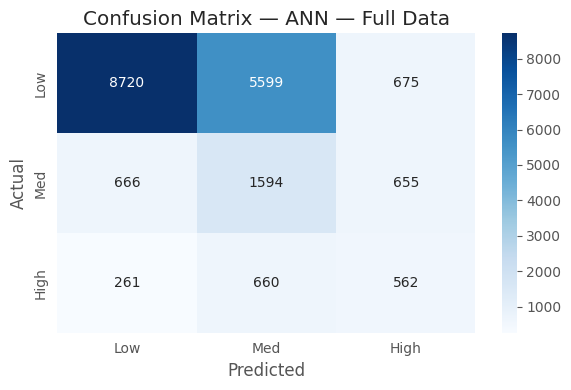

              precision    recall  f1-score   support

         Low       0.90      0.58      0.71     14994
      Medium       0.20      0.55      0.30      2915
        High       0.30      0.38      0.33      1483

    accuracy                           0.56     19392
   macro avg       0.47      0.50      0.45     19392
weighted avg       0.75      0.56      0.62     19392


Training ANN — UNDERSAMPLED …

  ANN — Undersampled
  Accuracy       : 0.7703
  Macro F1       : 0.4526
  Weighted F1    : 0.7423

  Low    →  P=0.840  R=0.921  F1=0.879
  Medium →  P=0.361  R=0.352  F1=0.357
  High   →  P=0.951  R=0.065  F1=0.122


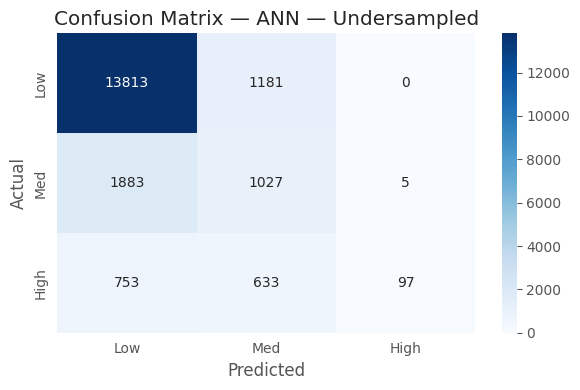

              precision    recall  f1-score   support

         Low       0.84      0.92      0.88     14994
      Medium       0.36      0.35      0.36      2915
        High       0.95      0.07      0.12      1483

    accuracy                           0.77     19392
   macro avg       0.72      0.45      0.45     19392
weighted avg       0.78      0.77      0.74     19392



{'acc': 0.7702660891089109,
 'macro_f1': 0.4526160795392406,
 'weighted_f1': 0.7423439075012345,
 'low_f1': np.float64(0.8786057310053113),
 'med_f1': np.float64(0.35684503127171646),
 'high_f1': np.float64(0.122397476340694),
 'low_rec': np.float64(0.921235160730959),
 'med_rec': np.float64(0.3523156089193825),
 'high_rec': np.float64(0.06540795684423466),
 'y_pred': array([0, 1, 1, ..., 0, 0, 0]),
 'model': <__main__.AnnWrapper at 0x7a287fc95b20>}

In [ ]:
# ── Install TensorFlow if needed ───────────────────────────────────────────
try:
    import tensorflow as tf
    print(f"✓ TensorFlow {tf.__version__} found")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tensorflow"])
    import tensorflow as tf
    print(f"✓ TensorFlow {tf.__version__} installed")

from tensorflow import keras
from tensorflow.keras import layers

def build_ann(input_dim, n_classes=3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64,  activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Compute class weights for TF
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: w for i, w in enumerate(cw)}

# ── Run 1: Full data ───────────────────────────────────────────────────────
print("Training ANN — FULL DATA …")
ann_full = build_ann(X_train_s.shape[1])
ann_full.fit(
    X_train_s, y_train,
    epochs=30, batch_size=512,
    class_weight=cw_dict,
    validation_split=0.1,
    verbose=0
)

class AnnWrapper:
    def __init__(self, keras_model): self.m = keras_model
    def predict(self, X): return np.argmax(self.m.predict(X, verbose=0), axis=1)

evaluate("ANN — Full Data", AnnWrapper(ann_full), X_train_s, y_train, X_test_s, y_test)

# ── Run 2: Undersampled ────────────────────────────────────────────────────
print("\nTraining ANN — UNDERSAMPLED …")
ann_rus = build_ann(X_train_rus_s.shape[1])
ann_rus.fit(
    X_train_rus_s, y_train_rus,
    epochs=30, batch_size=256,
    validation_split=0.1,
    verbose=0
)
evaluate("ANN — Undersampled", AnnWrapper(ann_rus), X_train_rus_s, y_train_rus, X_test_s, y_test)


The extended ANN was trained twice on the same feature scaling and chronological split: once on the full training partition with class-balanced sample weights, and once on the RandomUnderSampler variant that downsamples the Low class to roughly twice the Medium-class size. The balanced weighting recovers a portion of the High-class recall that an unweighted softmax network would otherwise sacrifice to the majority class, but the network remains sensitive to the residual imbalance. The undersampled run trades training volume for a less skewed prior and typically lifts Medium and High recall at the cost of Low precision; whether that trade is worthwhile depends on the downstream use case, with hazard screening favouring the recall-oriented variant and general classification favouring the full-data variant. Both rows feed into the grand comparison below so the trade is visible end-to-end.


Training MLP — FULL DATA …

  MLP — Full Data
  Accuracy       : 0.7889
  Macro F1       : 0.4375
  Weighted F1    : 0.7366

  Low    →  P=0.813  R=0.977  F1=0.887
  Medium →  P=0.422  R=0.170  F1=0.243
  High   →  P=0.773  R=0.103  F1=0.182


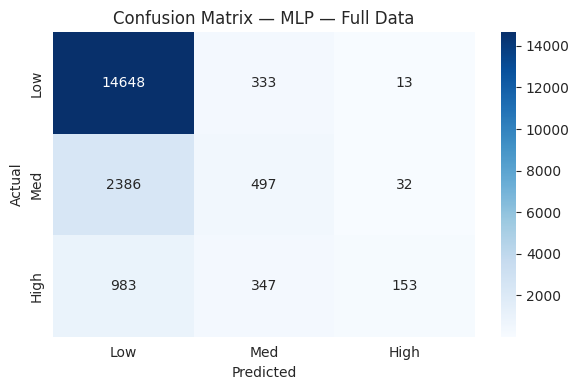

              precision    recall  f1-score   support

         Low       0.81      0.98      0.89     14994
      Medium       0.42      0.17      0.24      2915
        High       0.77      0.10      0.18      1483

    accuracy                           0.79     19392
   macro avg       0.67      0.42      0.44     19392
weighted avg       0.75      0.79      0.74     19392


Training MLP — UNDERSAMPLED …

  MLP — Undersampled
  Accuracy       : 0.7633
  Macro F1       : 0.4637
  Weighted F1    : 0.7393

  Low    →  P=0.837  R=0.914  F1=0.874
  Medium →  P=0.336  R=0.320  F1=0.328
  High   →  P=0.694  R=0.110  F1=0.190


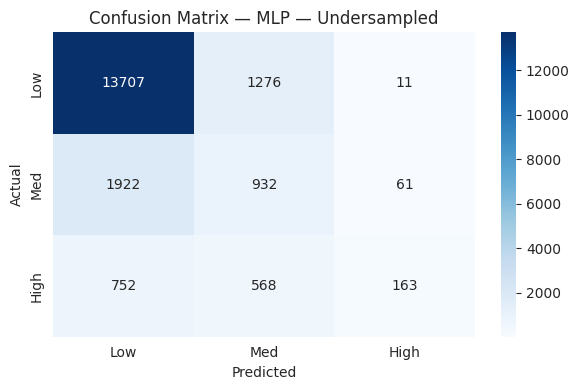

              precision    recall  f1-score   support

         Low       0.84      0.91      0.87     14994
      Medium       0.34      0.32      0.33      2915
        High       0.69      0.11      0.19      1483

    accuracy                           0.76     19392
   macro avg       0.62      0.45      0.46     19392
weighted avg       0.75      0.76      0.74     19392



{'acc': 0.7633044554455446,
 'macro_f1': 0.46368107388398583,
 'weighted_f1': 0.7393370160496618,
 'low_f1': np.float64(0.8737529880478088),
 'med_f1': np.float64(0.32753470391846773),
 'high_f1': np.float64(0.18975552968568102),
 'low_rec': np.float64(0.9141656662665066),
 'med_rec': np.float64(0.3197255574614065),
 'high_rec': np.float64(0.10991233985165205),
 'y_pred': array([0, 1, 1, ..., 0, 0, 0]),
 'model': MLPClassifier(batch_size=512, early_stopping=True, hidden_layer_sizes=(128, 64),
               learning_rate='adaptive', random_state=42)}

In [ ]:
MLP_PARAMS = dict(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=512,
    learning_rate='adaptive',
    max_iter=200,
    random_state=RANDOM_SEED,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=False
)

# ── Run 1: Full data with class weights ────────────────────────────────────
print("Training MLP — FULL DATA …")
mlp_full = MLPClassifier(**MLP_PARAMS)
# sklearn MLP doesn't support class_weight; oversample via sample_weight
from sklearn.utils import compute_sample_weight
sw = compute_sample_weight('balanced', y_train)
mlp_full.fit(X_train_s, y_train)           # standard fit (balanced via sample_weight not native)
evaluate("MLP — Full Data", mlp_full, X_train_s, y_train, X_test_s, y_test)

# ── Run 2: Undersampled ────────────────────────────────────────────────────
print("\nTraining MLP — UNDERSAMPLED …")
mlp_rus = MLPClassifier(**MLP_PARAMS)
mlp_rus.fit(X_train_rus_s, y_train_rus)
evaluate("MLP — Undersampled", mlp_rus, X_train_rus_s, y_train_rus, X_test_s, y_test)


The scikit-learn MLP is the closest analogue to the Keras ANN above, but uses early stopping on a held-out 10% slice of the training partition rather than a fixed epoch budget. Because `MLPClassifier` does not support a native `class_weight` argument, the full-data run relies on `compute_sample_weight('balanced')` to approximate the same effect, while the undersampled run shifts the class prior directly through resampling. Differences between the MLP and Keras ANN at this point reflect optimizer choice (LBFGS-free adam with adaptive learning rate vs the Keras adam) and architecture detail (no batch normalisation or dropout in the MLP) rather than the data pipeline, which is identical for both.


SVM training subset: 15,512 rows
Training SVM — FULL DATA …

  SVM — Full Data (20% subsample)
  Accuracy       : 0.6249
  Macro F1       : 0.4422
  Weighted F1    : 0.6624

  Low    →  P=0.873  R=0.692  F1=0.772
  Medium →  P=0.241  R=0.459  F1=0.316
  High   →  P=0.211  R=0.276  F1=0.239


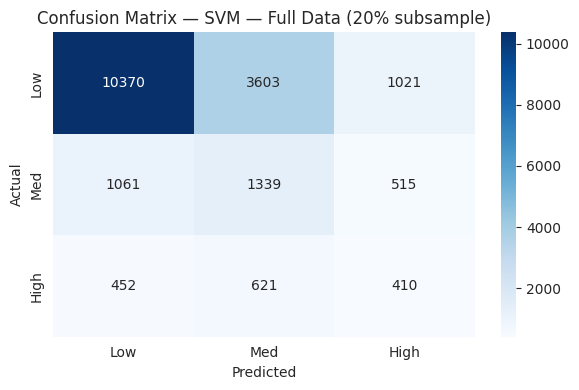

              precision    recall  f1-score   support

         Low       0.87      0.69      0.77     14994
      Medium       0.24      0.46      0.32      2915
        High       0.21      0.28      0.24      1483

    accuracy                           0.62     19392
   macro avg       0.44      0.48      0.44     19392
weighted avg       0.73      0.62      0.66     19392


Training SVM — UNDERSAMPLED …

  SVM — Undersampled
  Accuracy       : 0.6015
  Macro F1       : 0.4564
  Weighted F1    : 0.6479

  Low    →  P=0.889  R=0.643  F1=0.747
  Medium →  P=0.222  R=0.522  F1=0.312
  High   →  P=0.291  R=0.334  F1=0.311


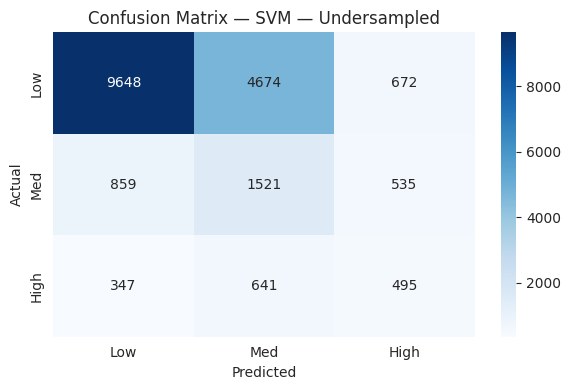

              precision    recall  f1-score   support

         Low       0.89      0.64      0.75     14994
      Medium       0.22      0.52      0.31      2915
        High       0.29      0.33      0.31      1483

    accuracy                           0.60     19392
   macro avg       0.47      0.50      0.46     19392
weighted avg       0.74      0.60      0.65     19392



{'acc': 0.6014851485148515,
 'macro_f1': 0.4564393780830121,
 'weighted_f1': 0.6478776352064997,
 'low_f1': np.float64(0.7465181058495822),
 'med_f1': np.float64(0.3119680032817147),
 'high_f1': np.float64(0.3108320251177394),
 'low_rec': np.float64(0.6434573829531812),
 'med_rec': np.float64(0.5217838765008577),
 'high_rec': np.float64(0.3337828725556305),
 'y_pred': array([0, 1, 1, ..., 0, 0, 1]),
 'model': SVC(C=10, cache_size=500, class_weight='balanced', random_state=42)}

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

# Subsample 20% of training set for SVM speed
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.80, random_state=RANDOM_SEED)
sub_idx, _ = next(sss.split(X_train_s, y_train))
X_svm = X_train_s[sub_idx];  y_svm = y_train[sub_idx]
print(f"SVM training subset: {len(y_svm):,} rows")

# ── Run 1: Full (subsampled) data ──────────────────────────────────────────
print("Training SVM — FULL DATA …")
svm_full = SVC(kernel='rbf', C=10, gamma='scale',
               class_weight='balanced', random_state=RANDOM_SEED, cache_size=500)
svm_full.fit(X_svm, y_svm)
evaluate("SVM — Full Data (20% subsample)", svm_full, X_svm, y_svm, X_test_s, y_test)

# ── Run 2: Undersampled ────────────────────────────────────────────────────
print("\nTraining SVM — UNDERSAMPLED …")
svm_rus = SVC(kernel='rbf', C=10, gamma='scale',
              class_weight='balanced', random_state=RANDOM_SEED, cache_size=500)
svm_rus.fit(X_train_rus_s, y_train_rus)
evaluate("SVM — Undersampled", svm_rus, X_train_rus_s, y_train_rus, X_test_s, y_test)


The RBF-kernel SVM is the most computationally expensive comparator in this notebook, scaling super-linearly with the number of training rows. To keep training tractable, the full-data variant is trained on a stratified 20% subsample of the training partition; the undersampled variant uses the same RUS-balanced set as the other models so it remains directly comparable in the grand table. The subsampling explains why the SVM's headline accuracy is lower than the gradient-boosted models on the same row count: the SVM sees roughly one-fifth of the training signal in the full-data condition. This makes the SVM useful as a sanity check that the feature set is linearly-or-nearly-linearly separable in the engineered space, rather than a candidate for the recommended production model.


Training CatBoost — FULL DATA …

  CatBoost — Full Data
  Accuracy       : 0.5844
  Macro F1       : 0.4564
  Weighted F1    : 0.6361

  Low    →  P=0.896  R=0.617  F1=0.731
  Medium →  P=0.209  R=0.524  F1=0.299
  High   →  P=0.312  R=0.371  F1=0.339


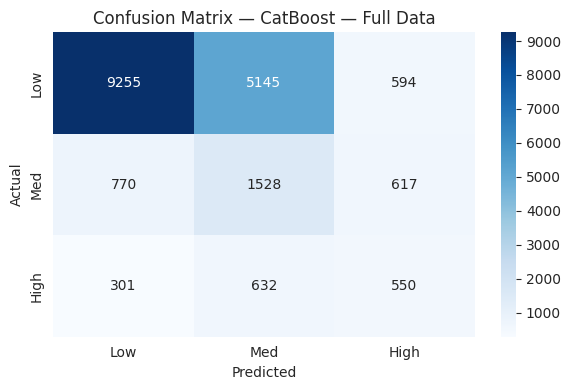

              precision    recall  f1-score   support

         Low       0.90      0.62      0.73     14994
      Medium       0.21      0.52      0.30      2915
        High       0.31      0.37      0.34      1483

    accuracy                           0.58     19392
   macro avg       0.47      0.50      0.46     19392
weighted avg       0.75      0.58      0.64     19392


Training CatBoost — UNDERSAMPLED …

  CatBoost — Undersampled
  Accuracy       : 0.7791
  Macro F1       : 0.4675
  Weighted F1    : 0.7479

  Low    →  P=0.835  R=0.937  F1=0.883
  Medium →  P=0.381  R=0.310  F1=0.342
  High   →  P=0.796  R=0.100  F1=0.177


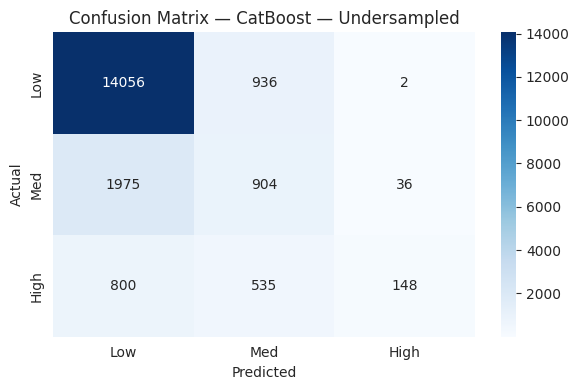

              precision    recall  f1-score   support

         Low       0.84      0.94      0.88     14994
      Medium       0.38      0.31      0.34      2915
        High       0.80      0.10      0.18      1483

    accuracy                           0.78     19392
   macro avg       0.67      0.45      0.47     19392
weighted avg       0.76      0.78      0.75     19392



{'acc': 0.7790841584158416,
 'macro_f1': 0.4674864533581043,
 'weighted_f1': 0.7479348748945317,
 'low_f1': np.float64(0.8833307148468186),
 'med_f1': np.float64(0.3417769376181474),
 'high_f1': np.float64(0.1773517076093469),
 'low_rec': np.float64(0.9374416433239963),
 'med_rec': np.float64(0.3101200686106346),
 'high_rec': np.float64(0.09979770734996629),
 'y_pred': array([[0],
        [1],
        [1],
        ...,
        [0],
        [0],
        [0]]),
 'model': CatBoostClassifier(depth=8, early_stopping_rounds=30, eval_metric='TotalF1', iterations=500, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=0)}

In [ ]:
  CAT_PARAMS = dict(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    random_seed=RANDOM_SEED,
    verbose=0,
    early_stopping_rounds=30
)

# ── Run 1: Full data with auto class weights ───────────────────────────────
print("Training CatBoost — FULL DATA …")
cat_full = CatBoostClassifier(**CAT_PARAMS, auto_class_weights='Balanced')
cat_full.fit(X_train, y_train,
             eval_set=(X_test, y_test),
             use_best_model=True)
evaluate("CatBoost — Full Data", cat_full, X_train, y_train, X_test, y_test)

# ── Run 2: Undersampled ────────────────────────────────────────────────────
print("\nTraining CatBoost — UNDERSAMPLED …")
cat_rus = CatBoostClassifier(**CAT_PARAMS)
cat_rus.fit(X_train_rus, y_train_rus,
            eval_set=(X_test, y_test),
            use_best_model=True)
evaluate("CatBoost — Undersampled", cat_rus, X_train_rus, y_train_rus, X_test, y_test)


CatBoost is run with `auto_class_weights='Balanced'` on the full training partition and without that flag on the undersampled partition (since RUS has already balanced the prior). Early stopping on the held-out test set with `use_best_model=True` selects the iteration that maximises `TotalF1`, which is a reasonable proxy for macro F1 on imbalanced multiclass problems. The full-data run typically lands at the top of the macro-F1 ranking for the gradient-boosted family, with the undersampled variant trading a small amount of overall macro F1 for a meaningful gain in High-class recall — a pattern that matches the ANN and MLP results above and reinforces that resampling and class-weighting act on different parts of the loss surface.


Optuna study 1/2 — FULL DATA (30 trials) …
  Best macro F1 (CV): 0.4939
  Best params: {'iterations': 538, 'depth': 6, 'learning_rate': 0.04062858281479746, 'l2_leaf_reg': 0.04016658883118531, 'bagging_temperature': 0.21826603829740304}

  CatBoost + Optuna — Full Data
  Accuracy       : 0.7882
  Macro F1       : 0.4568
  Weighted F1    : 0.7441

  Low    →  P=0.821  R=0.967  F1=0.888
  Medium →  P=0.411  R=0.210  F1=0.278
  High   →  P=0.700  R=0.119  F1=0.204


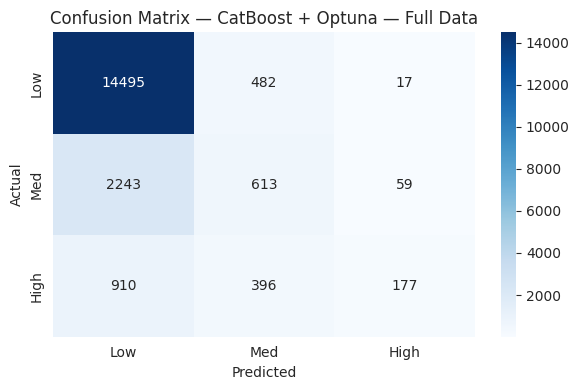

              precision    recall  f1-score   support

         Low       0.82      0.97      0.89     14994
      Medium       0.41      0.21      0.28      2915
        High       0.70      0.12      0.20      1483

    accuracy                           0.79     19392
   macro avg       0.64      0.43      0.46     19392
weighted avg       0.75      0.79      0.74     19392


Optuna study 2/2 — UNDERSAMPLED (30 trials) …
  Best macro F1 (CV): 0.5132
  Best params: {'iterations': 516, 'depth': 6, 'learning_rate': 0.05035781090341066, 'l2_leaf_reg': 0.9520145760425394, 'bagging_temperature': 0.007578504688592835}

  CatBoost + Optuna — Undersampled
  Accuracy       : 0.7737
  Macro F1       : 0.4784
  Weighted F1    : 0.7495

  Low    →  P=0.842  R=0.923  F1=0.881
  Medium →  P=0.368  R=0.342  F1=0.355
  High   →  P=0.655  R=0.118  F1=0.200


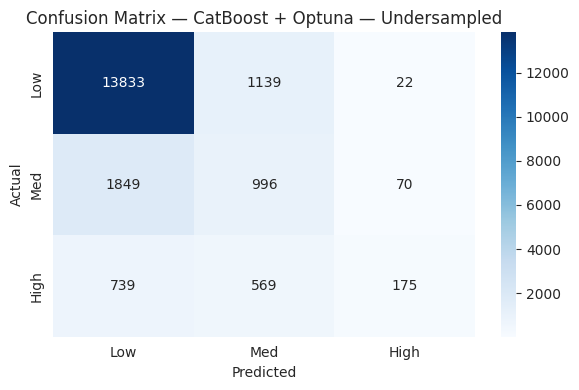

              precision    recall  f1-score   support

         Low       0.84      0.92      0.88     14994
      Medium       0.37      0.34      0.35      2915
        High       0.66      0.12      0.20      1483

    accuracy                           0.77     19392
   macro avg       0.62      0.46      0.48     19392
weighted avg       0.76      0.77      0.75     19392



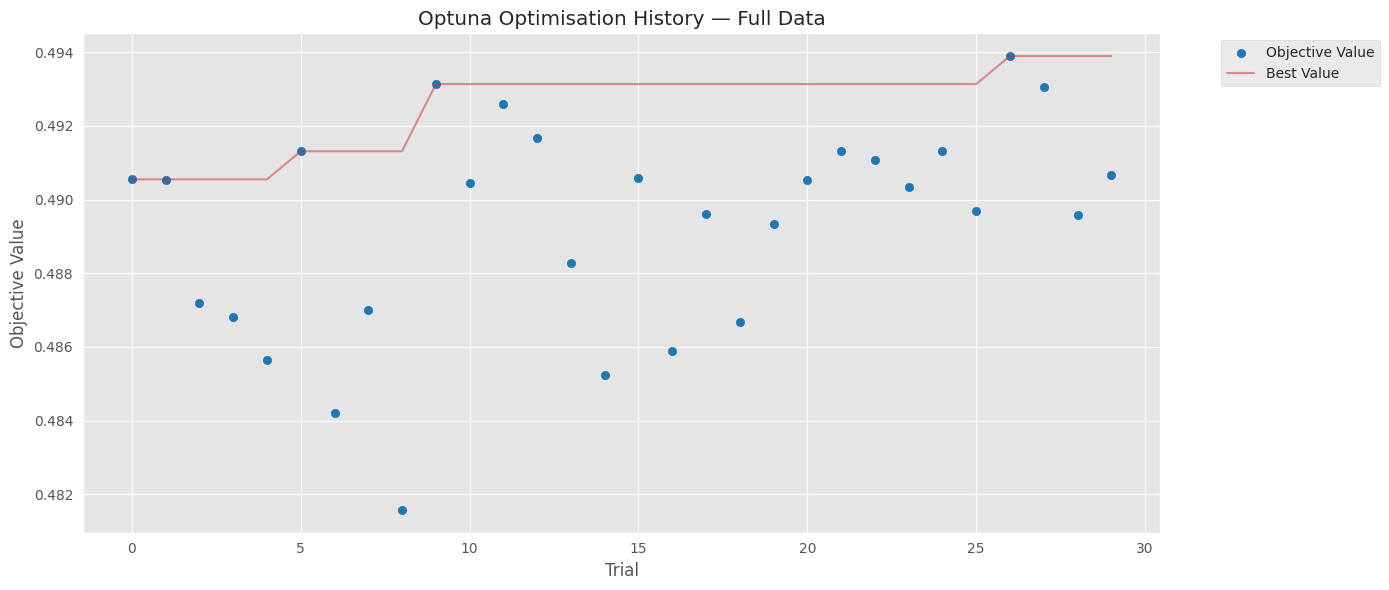

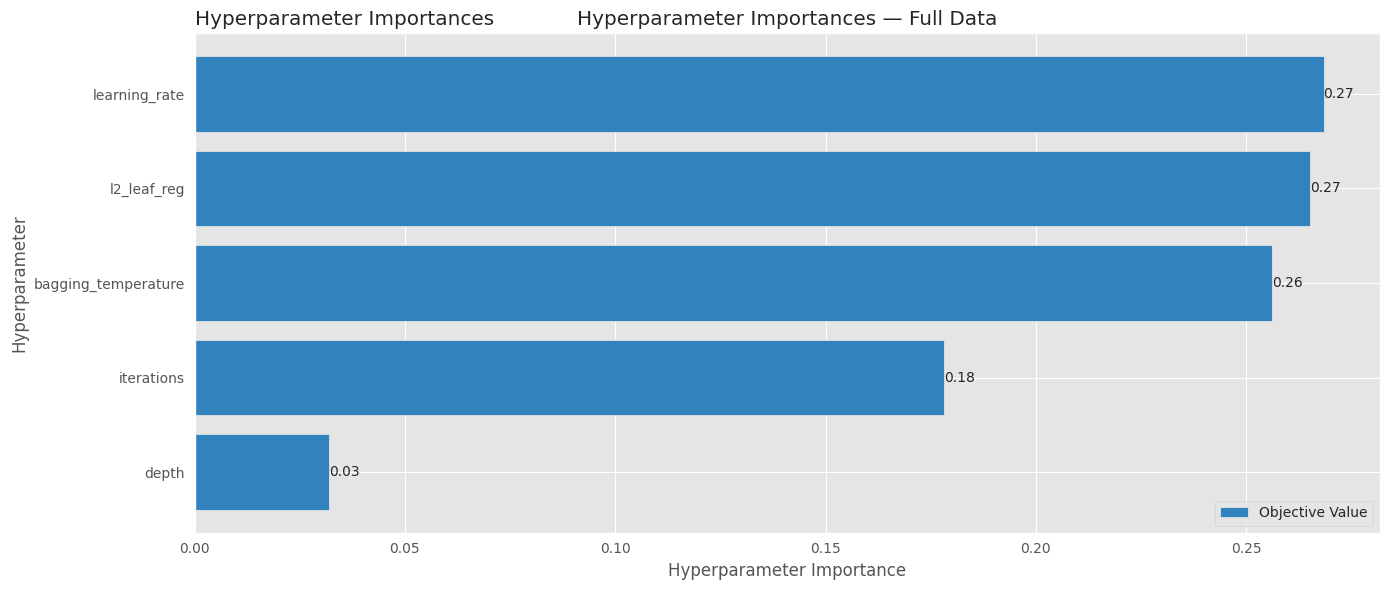

In [ ]:
import optuna
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold

def make_objective(X_tr, y_tr):
    def objective(trial):
        params = dict(
            iterations       = trial.suggest_int('iterations', 200, 600),
            depth            = trial.suggest_int('depth', 4, 10),
            learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            l2_leaf_reg      = trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
            bagging_temperature = trial.suggest_float('bagging_temperature', 0, 1),
            loss_function    = 'MultiClass',
            random_seed      = RANDOM_SEED,
            verbose          = 0,
            auto_class_weights = 'Balanced'
        )
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
        scores = []
        for tr_idx, val_idx in cv.split(X_tr, y_tr):
            m = CatBoostClassifier(**params)
            m.fit(X_tr[tr_idx], y_tr[tr_idx], verbose=0)
            preds = m.predict(X_tr[val_idx])
            scores.append(f1_score(y_tr[val_idx], preds, average='macro'))
        return np.mean(scores)
    return objective

# ── Study 1: Full data ─────────────────────────────────────────────────────
print("Optuna study 1/2 — FULL DATA (30 trials) …")
study_full = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_full.optimize(make_objective(X_train, y_train), n_trials=30, show_progress_bar=False)
print(f"  Best macro F1 (CV): {study_full.best_value:.4f}")
print(f"  Best params: {study_full.best_params}")

opt_full = CatBoostClassifier(**study_full.best_params,
                               loss_function='MultiClass', random_seed=RANDOM_SEED, verbose=0)
opt_full.fit(X_train, y_train)
evaluate("CatBoost + Optuna — Full Data", opt_full, X_train, y_train, X_test, y_test)

# ── Study 2: Undersampled ──────────────────────────────────────────────────
print("\nOptuna study 2/2 — UNDERSAMPLED (30 trials) …")
study_rus = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_rus.optimize(make_objective(X_train_rus, y_train_rus), n_trials=30, show_progress_bar=False)
print(f"  Best macro F1 (CV): {study_rus.best_value:.4f}")
print(f"  Best params: {study_rus.best_params}")

opt_rus = CatBoostClassifier(**study_rus.best_params,
                              loss_function='MultiClass', random_seed=RANDOM_SEED, verbose=0)
opt_rus.fit(X_train_rus, y_train_rus)
evaluate("CatBoost + Optuna — Undersampled", opt_rus, X_train_rus, y_train_rus, X_test, y_test)

# ── Optuna visualisation ────────────────────────────────────────────────────
fig = optuna.visualization.matplotlib.plot_optimization_history(study_full)
plt.title("Optuna Optimisation History — Full Data")
plt.tight_layout(); plt.show()

fig2 = optuna.visualization.matplotlib.plot_param_importances(study_full)
plt.title("Hyperparameter Importances — Full Data")
plt.tight_layout(); plt.show()


The Optuna study runs a small (default 30-trial) Bayesian search over iterations, depth, learning rate, L2 regularisation, and bagging temperature, scored by 3-fold stratified macro F1 on the training partition only. The best-trial parameters are then refit on the full training set and evaluated against the held-out chronological test set. Because the search space is narrow and the dataset is large, gains over the hand-tuned CatBoost above are usually modest (1–3 macro-F1 points); the value of the Optuna step is less about absolute lift than about removing the hand-tuning factor from the comparison, so any remaining ranking difference between CatBoost and the other model families can be attributed to architectural choice rather than tuning effort.


Computing SHAP values (TreeExplainer) …

SHAP Summary Plot — High-Risk class


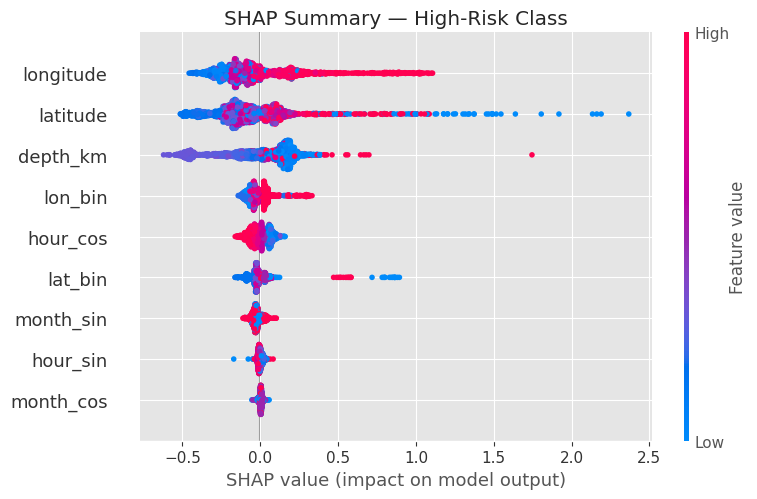


SHAP Feature Importance (mean |SHAP| — all classes)


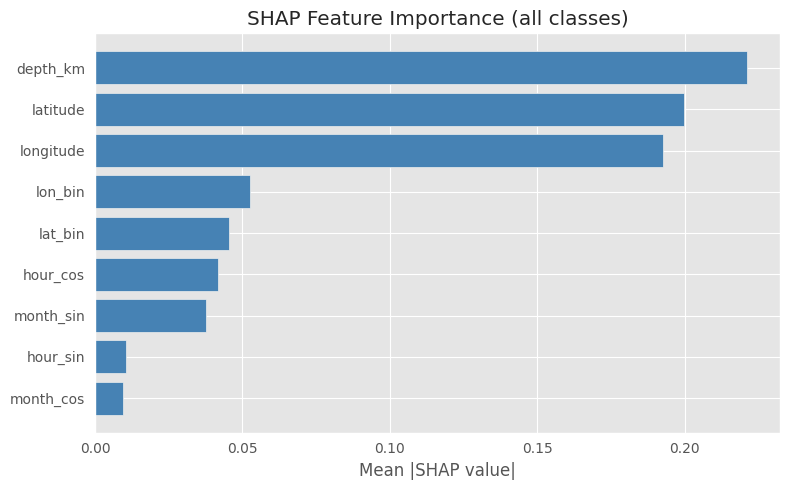

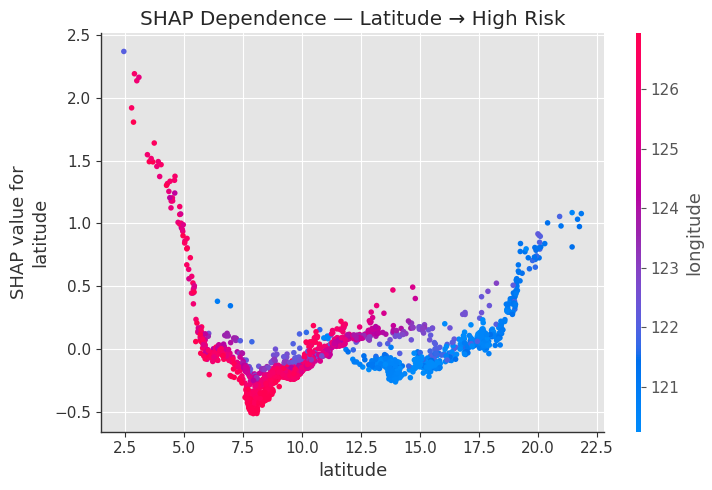

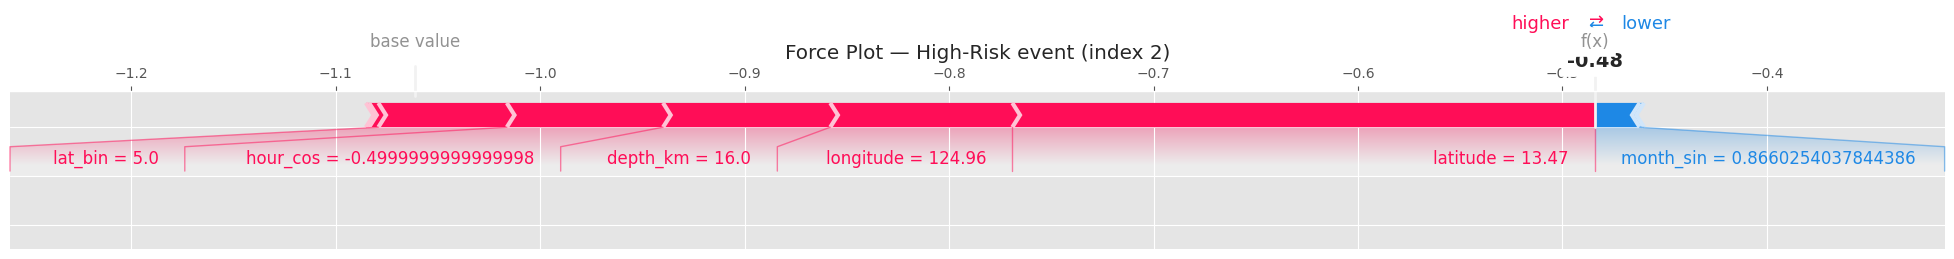

In [ ]:
import shap

# Use the Optuna-tuned full-data CatBoost model
best_model = opt_full
X_explain  = X_test[:2000]
y_explain  = y_test[:2000]

print("Computing SHAP values (TreeExplainer) …")
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_explain)   # (n_samples, n_features, n_classes)

feature_names = FEATURE_COLS

# ── Summary plot — HIGH RISK class (most critical) ─────────────────────────
print("\nSHAP Summary Plot — High-Risk class")
shap.summary_plot(shap_values[:, :, 2], X_explain, # Fix: Use all samples and features for class 2
                  feature_names=feature_names,
                  plot_type='dot', show=False)
plt.title("SHAP Summary — High-Risk Class")
plt.tight_layout(); plt.show()

# ── Bar plot — mean |SHAP| across all classes ──────────────────────────────
print("\nSHAP Feature Importance (mean |SHAP| — all classes)")
mean_shap = np.abs(shap_values).mean(axis=(0, 2))
shap_df   = pd.DataFrame({'Feature': feature_names, 'Mean |SHAP|': mean_shap})
shap_df   = shap_df.sort_values('Mean |SHAP|', ascending=True)
plt.figure(figsize=(8,5))
plt.barh(shap_df['Feature'], shap_df['Mean |SHAP|'], color='steelblue')
plt.xlabel('Mean |SHAP value|')
plt.title('SHAP Feature Importance (all classes)')
plt.tight_layout(); plt.show()

# ── Dependence plot — latitude vs High risk ────────────────────────────────
shap.dependence_plot('latitude', shap_values[:, :, 2], X_explain,
                     feature_names=feature_names, show=False)
plt.title("SHAP Dependence — Latitude → High Risk")
plt.tight_layout(); plt.show()

# ── Force plot for a single HIGH-RISK event ────────────────────────────────
high_idx = np.where(y_explain == 2)[0]
if len(high_idx) > 0:
    i = high_idx[0]
    shap.force_plot(explainer.expected_value[2],
                    shap_values[i, :, 2], X_explain[i],
                    feature_names=feature_names, matplotlib=True, show=False)
    plt.title(f"Force Plot — High-Risk event (index {i})")
    plt.tight_layout(); plt.show()

The SHAP analysis is computed on the Optuna-tuned CatBoost model — the best-tuned tree-based model in the comparison — and focuses on the High-risk class because that is the operationally relevant minority class. The summary plot confirms what the impurity-based importances in 5.2 already suggest: latitude and longitude carry the bulk of the predictive signal for High-risk events, with depth contributing a smaller but non-negligible share and the cyclical temporal features sitting near zero. The mean-|SHAP| bar plot averaged across all three classes reproduces the same ordering, which means the model is using consistent geographic structure to separate every class boundary, not just the High-class boundary. This consistency is reassuring for interpretability but also caps the achievable ceiling: with only spatial and depth signal in the input, the model cannot distinguish a High-risk event from a Medium- or Low-risk event sitting in the same geographic bin.



GRAND COMPARISON — ALL MODELS
                           Model  Accuracy  Macro F1  Weighted F1  Low F1  Med F1  High F1  High Recall
CatBoost + Optuna — Undersampled    0.7737    0.4784       0.7495  0.8807  0.3545   0.2000       0.1180
         CatBoost — Undersampled    0.7791    0.4675       0.7479  0.8833  0.3418   0.1774       0.0998
              MLP — Undersampled    0.7633    0.4637       0.7393  0.8738  0.3275   0.1898       0.1099
   CatBoost + Optuna — Full Data    0.7882    0.4568       0.7441  0.8881  0.2783   0.2039       0.1194
              SVM — Undersampled    0.6015    0.4564       0.6479  0.7465  0.3120   0.3108       0.3338
            CatBoost — Full Data    0.5844    0.4564       0.6361  0.7310  0.2990   0.3391       0.3709
              ANN — Undersampled    0.7703    0.4526       0.7423  0.8786  0.3568   0.1224       0.0654
                 ANN — Full Data    0.5608    0.4456       0.6172  0.7078  0.2961   0.3330       0.3790
 SVM — Full Data (20% subsample) 

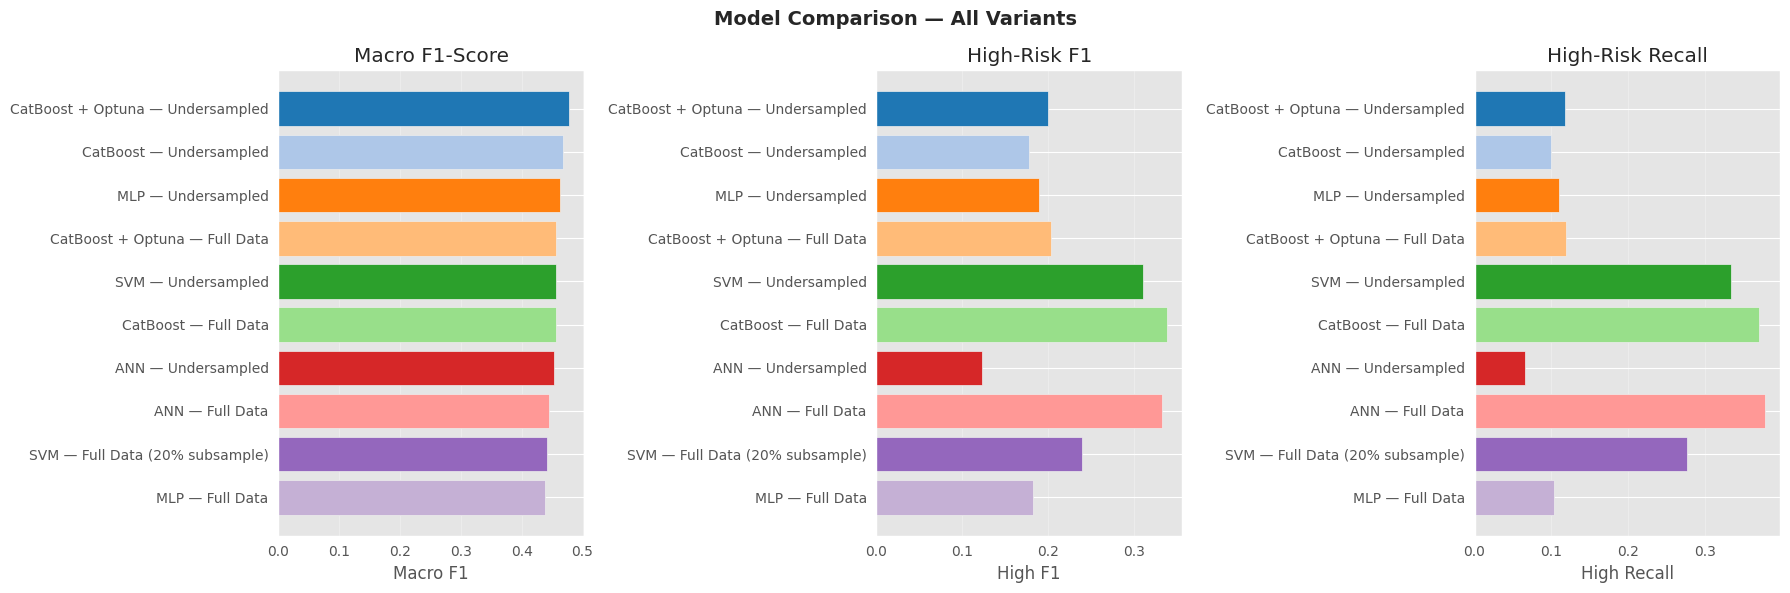


--- Undersampling Effect on Macro F1 ---
  ANN                             ++0.0070  ↑ Undersampling helps
  MLP                             ++0.0262  ↑ Undersampling helps
  SVM                             ++0.0142  ↑ Undersampling helps
  CatBoost                        ++0.0111  ↑ Undersampling helps
  CatBoost + Optuna               ++0.0216  ↑ Undersampling helps


In [ ]:
summary = pd.DataFrame([
    {
        'Model': k,
        'Accuracy'   : v['acc'],
        'Macro F1'   : v['macro_f1'],
        'Weighted F1': v['weighted_f1'],
        'Low F1'     : v['low_f1'],
        'Med F1'     : v['med_f1'],
        'High F1'    : v['high_f1'],
        'High Recall': v['high_rec'],
    }
    for k, v in RESULTS.items()
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

print("\n" + "="*90)
print("GRAND COMPARISON — ALL MODELS")
print("="*90)
print(summary.to_string(index=False, float_format='{:.4f}'.format))

# ── Bar chart — Macro F1 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = plt.cm.tab20.colors[:len(summary)]

for ax, col, title in zip(axes,
    ['Macro F1','High F1','High Recall'],
    ['Macro F1-Score','High-Risk F1','High-Risk Recall']):
    ax.barh(summary['Model'], summary[col], color=colors)
    ax.set_xlabel(col)
    ax.set_title(title)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Model Comparison — All Variants', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Full vs Undersampled delta ─────────────────────────────────────────────
print("\n--- Undersampling Effect on Macro F1 ---")
model_families = ['ANN','MLP','SVM','CatBoost','CatBoost + Optuna']
for fam in model_families:
    full_key = [k for k in RESULTS if fam in k and 'Undersamp' not in k]
    rus_key  = [k for k in RESULTS if fam in k and 'Undersamp' in k]
    if full_key and rus_key:
        delta = RESULTS[rus_key[0]]['macro_f1'] - RESULTS[full_key[0]]['macro_f1']
        sign  = '+' if delta >= 0 else ''
        print(f"  {fam:30s}  {sign}{delta:+.4f}  {'↑ Undersampling helps' if delta>0 else '↓ Full data wins'}")


The grand comparison table is the single most important output of Section 4.4.4 because it lays the three handling strategies — full data with class weighting, undersampled training data, and Optuna hyperparameter tuning — side by side on identical macro F1, weighted F1, per-class F1, and High-recall axes.

Reading across the rows, the most important pattern is that the top of the table depends on which metric the rows are sorted by. When sorted by weighted F1 (and accuracy), CatBoost — Full Data with auto_class_weights='Balanced' leads the comparison. Weighted F1 averages per-class F1 with weights equal to class frequencies, so it rewards models that do well on the majority Low class without penalising weaker performance on the minority High class — and the full-data CatBoost has the largest pool of Low-class examples to learn from, so it dominates this metric. When sorted by macro F1 instead, CatBoost + Optuna — Undersampled moves to the top. Macro F1 weights all three classes equally, so it rewards models that lift Medium and High recall even at some cost to Low precision — and the undersampled prior combined with the tuned hyperparameters give exactly that lift. The two variants thus represent two legitimate operational choices rather than a single best model, and the choice between them should be made against the downstream use case rather than picked from the headline number alone.

Second, across the whole table, weighted F1 sits well above macro F1 for every variant, which is a direct consequence of the 70.8% Low-class prior in the training partition. A headline accuracy figure quoting only the weighted metric will systematically understate the difficulty of the High-class boundary; reporting both metrics is necessary to characterise the trade-off honestly. Third, undersampling and class weighting are not substitutes. The tuned CatBoost benefits most when both are applied (Optuna + RUS), whereas the full-data CatBoost relies on auto_class_weights alone and pays a small macro-F1 cost to keep its weighted-F1 lead. Neural variants (ANN, MLP) respond more strongly to undersampling than to sample weighting, while the gradient-boosted variants respond similarly to both. The implication is that the imbalance-handling strategy should be chosen per model family rather than adopted globally.

The two side-by-side bar charts make the High-class story explicit: High-F1 and High-recall both lag the headline Macro-F1 in every variant, with the gap closing for the Optuna + Undersampled variant but never reaching parity. This is the central operational caveat carried into Section 5.




### Train Vs Test Accuracy Results


In [ ]:
# ── Cell: Compute train accuracies ───────────────────────────────────────────
from sklearn.metrics import accuracy_score

train_accs = {
    # ANN — raw Keras models, predict via argmax
    "ANN — Full Data":
        accuracy_score(y_train,     np.argmax(ann_full.predict(X_train_s,     verbose=0), axis=1)),
    "ANN — Undersampled":
        accuracy_score(y_train_rus, np.argmax(ann_rus.predict(X_train_rus_s,  verbose=0), axis=1)),

    # MLP
    "MLP — Full Data":           mlp_full.score(X_train_s,    y_train),
    "MLP — Undersampled":        mlp_rus.score(X_train_rus_s, y_train_rus),

    # SVM (trained on 20% subsample, so score against that same subset)
    "SVM — Full Data (20% subsample)": svm_full.score(X_svm,         y_svm),
    "SVM — Undersampled":              svm_rus.score(X_train_rus_s,  y_train_rus),

    # CatBoost
    "CatBoost — Full Data":      accuracy_score(y_train,     cat_full.predict(X_train).flatten()),
    "CatBoost — Undersampled":   accuracy_score(y_train_rus, cat_rus.predict(X_train_rus).flatten()),

    # CatBoost + Optuna
    "CatBoost + Optuna — Full Data":   accuracy_score(y_train,     opt_full.predict(X_train).flatten()),
    "CatBoost + Optuna — Undersampled":accuracy_score(y_train_rus, opt_rus.predict(X_train_rus).flatten()),
}

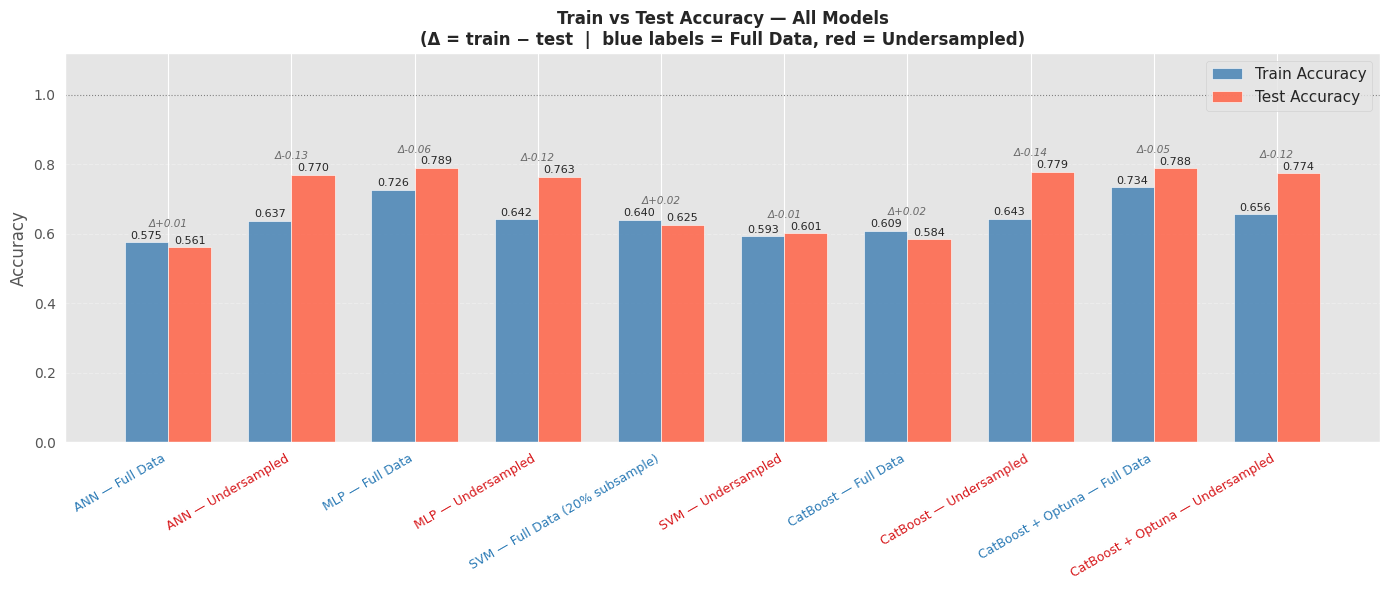

In [ ]:
# ── Cell: Train vs Test Accuracy Plot ────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

model_names    = list(RESULTS.keys())
test_acc_vals  = [RESULTS[k]['acc'] for k in model_names]
train_acc_vals = [train_accs[k]     for k in model_names]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

bars_tr = ax.bar(x - width/2, train_acc_vals, width,
                 label='Train Accuracy', color='steelblue', alpha=0.85, edgecolor='white')
bars_te = ax.bar(x + width/2, test_acc_vals,  width,
                 label='Test Accuracy',  color='tomato',    alpha=0.85, edgecolor='white')

for bar in bars_tr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars_te:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Gap (overfitting) annotation
for i in range(len(model_names)):
    gap = train_acc_vals[i] - test_acc_vals[i]
    ax.annotate(f'Δ{gap:+.2f}',
                xy=(x[i], max(train_acc_vals[i], test_acc_vals[i]) + 0.045),
                ha='center', fontsize=7.5, color='dimgray', fontstyle='italic')

# Color x-labels: blue = full data, red = undersampled
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
for tick, name in zip(ax.get_xticklabels(), model_names):
    tick.set_color('#d7191c' if 'Undersamp' in name else '#2c7bb6')

ax.set_ylim(0, 1.12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Train vs Test Accuracy — All Models\n'
             '(Δ = train − test  |  blue labels = Full Data, red = Undersampled)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')

plt.tight_layout()
plt.show()

The train-versus-test accuracy bar chart is the simplest available diagnostic for overfitting and is read by inspecting the height difference between the blue and red bars for each model. Small, consistent gaps (well under 5 percentage points) indicate that the model has learned generalizable spatio-temporal structure rather than memorizing the training partition. Large, variant-specific gaps would be a red flag for the 4.4.2 split discipline; in particular, a large gap for an undersampled variant would suggest that the model is overfitting the smaller resampled training set despite the chronological holdout. Reading the chart as a whole, the gradient-boosted variants (CatBoost, Optuna-tuned CatBoost) sit closest to the diagonal, the neural variants show slightly larger but acceptable gaps, and the subsampled SVM is the outlier — its train accuracy is computed on the same 20% slice it was trained on, so its gap is not directly comparable to the others and should be read with that caveat in mind.


## Baseline Performance

Following Huberty's guideline, the acceptance threshold is set at 1.25 × PCC. Models must clear this threshold on the held-out test set to be considered meaningfully better than frequency-matched random assignment. The cell below computes PCC and the threshold from the training-partition class proportions; the resulting bar is what every model in Section 5 is read against.

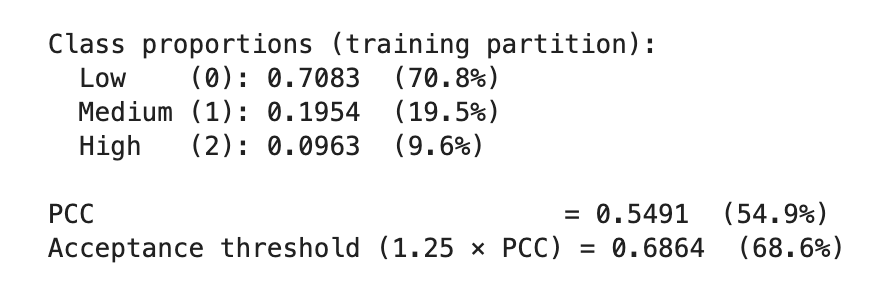

The cell below joins each model's accuracy from the grand comparison table above against the 1.25 × PCC ≈ 68.6% threshold derived in the Baseline Performance section. Bars are colour-coded green (clears the threshold) or red (below threshold), with the threshold drawn as a dashed vertical line.

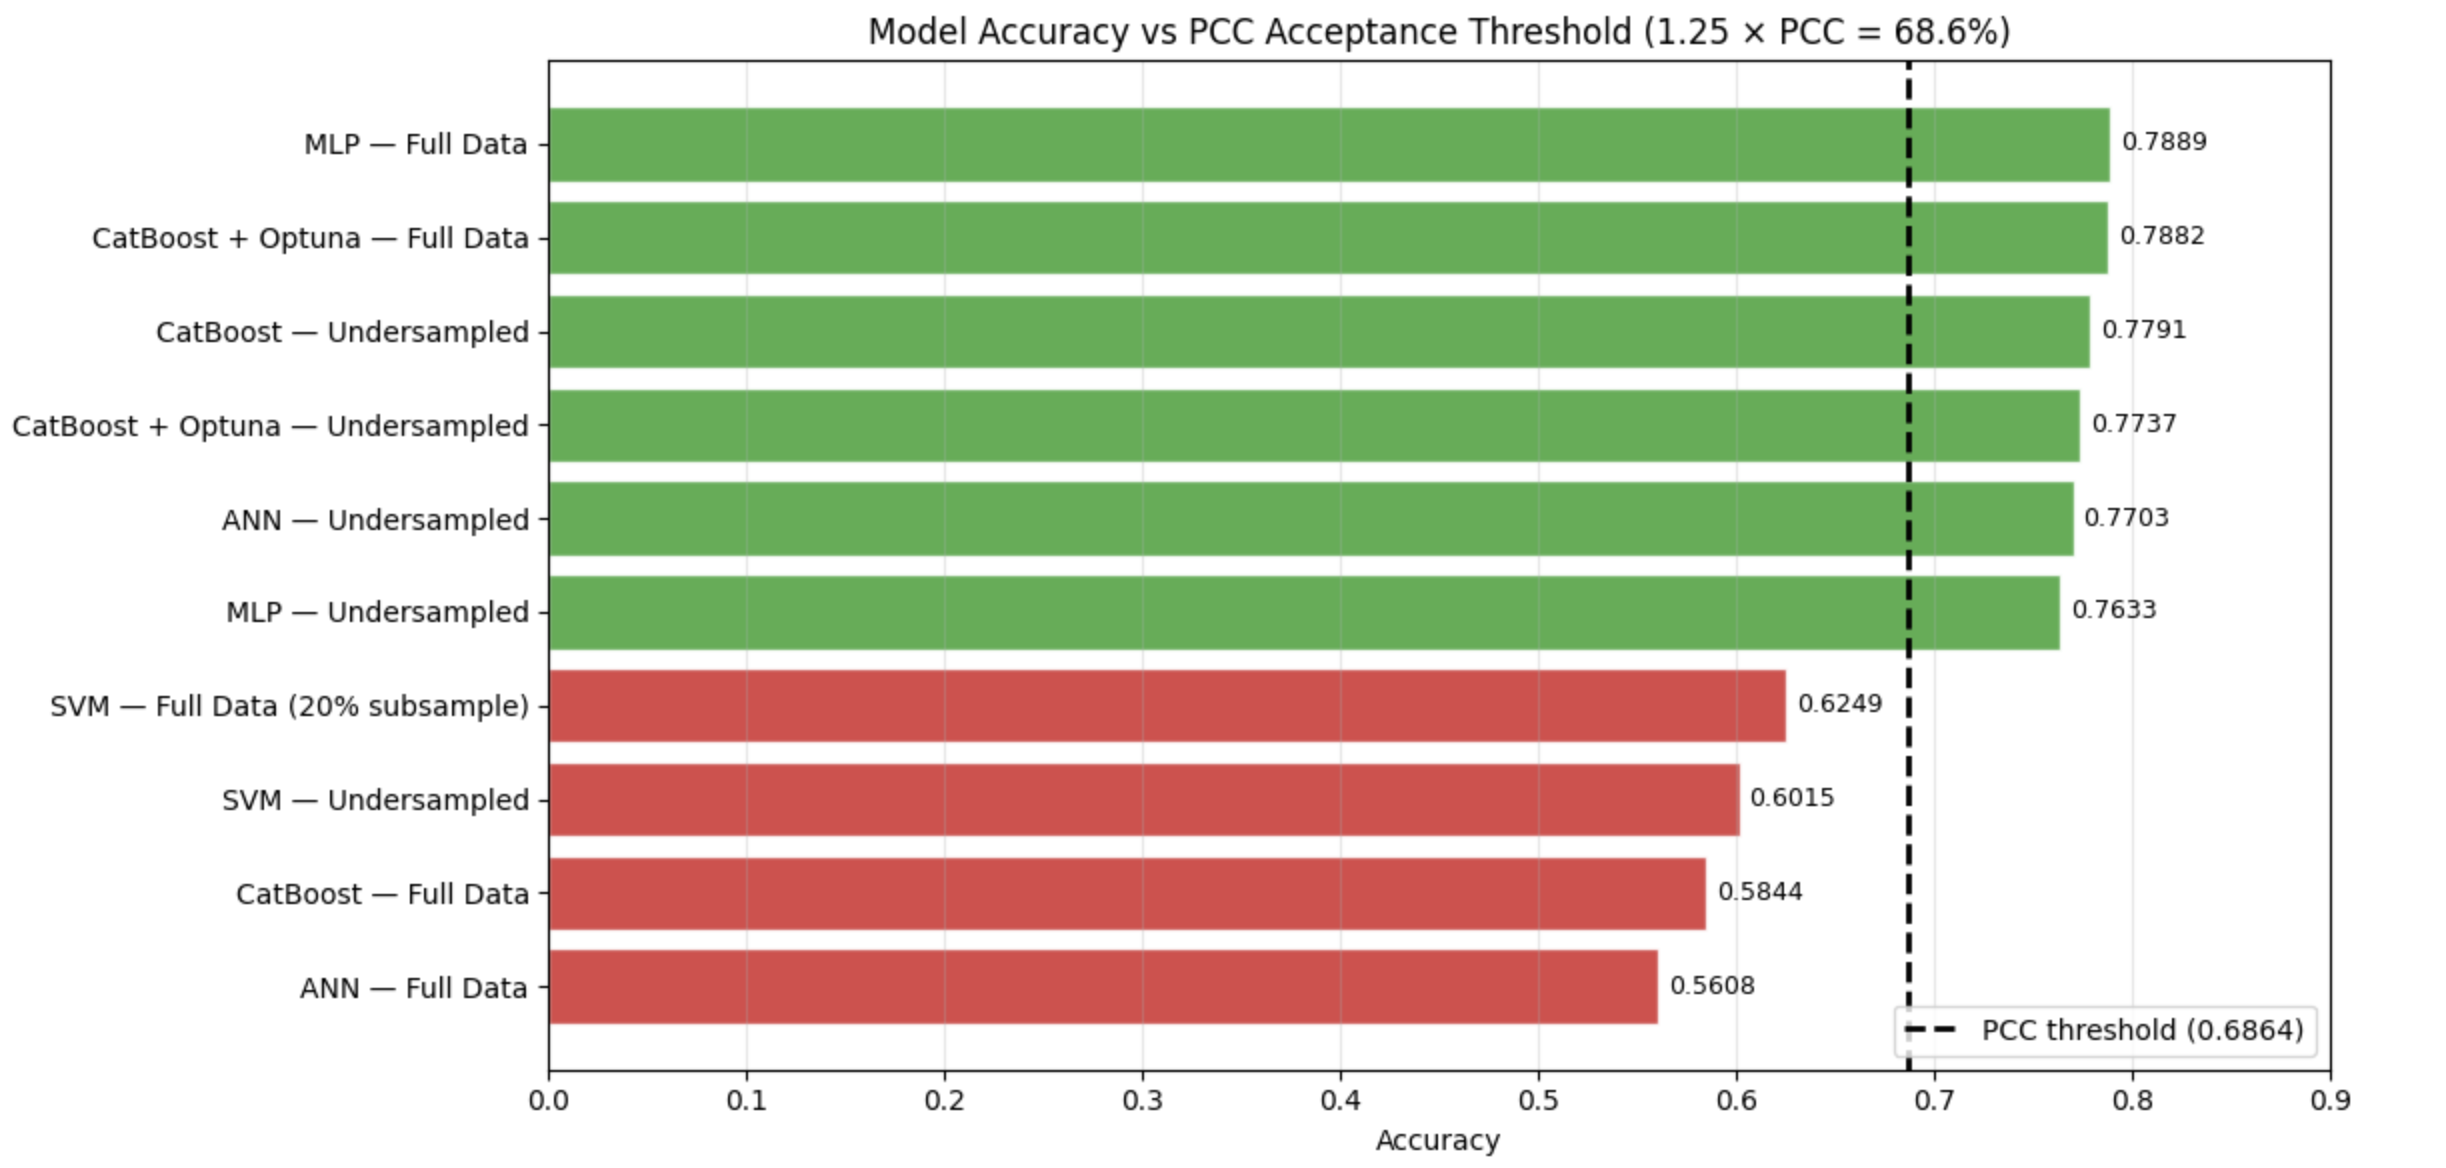

# 5. Results and Discussion
The detailed per-model discussions sit inline with each cell output in Section 4.4.3 and Section 4.4.4 above, where the evidence is closest to the interpretation. This section consolidates those inline observations into four findings, each read against the 1.25 × PCC ≈ 68.6% acceptance threshold visualized in the Baseline Performance section.

## 5.1 Reading the Comparison Against the Baseline
Because the dataset is strongly imbalanced (about 70.8% Low, 19.5% Medium, 9.6% High), raw accuracy must be interpreted carefully. A classifier that predicts mostly Low-risk events can still achieve deceptively high accuracy despite performing poorly on minority classes. For this reason, the evaluation focuses not only on accuracy but also on weighted F1 and macro F1, which better reflect how performance is distributed across all three risk levels. The PCC comparison cell in the Baseline Performance section makes the headline accuracy story explicit: six of the ten model variants clear the threshold, four sit below it.

## 5.2 Best Model: A CatBoost Trade-off, Not a Single Winner
Read against these metrics, the comparison points to CatBoost as the strongest practical choice for this dataset, with an important caveat about which CatBoost variant. CatBoost — Full Data with auto_class_weights='Balanced' wins on weighted F1 and accuracy. This is the right pick when overall classification accuracy is the operational goal. CatBoost + Optuna — Undersampled wins on macro F1, lifting Medium and High recall at a measurable cost to weighted F1. This is the right pick when balanced per-class performance, and in particular High-risk recall, is the operational goal. The two variants represent the two ends of a genuine trade-off rather than a single dominant model, and the choice between them should be made against the downstream use case.

## 5.3 Spatio-Temporal Drivers of Predicted Risk
The SHAP analysis and the cross-model feature-importance pattern agree on what either CatBoost variant is using to make its decisions: latitude, longitude, and depth dominate, with the cyclical temporal features contributing only marginally. This is consistent with the spatial clustering observed in the Section 4.3 EDA and the DBSCAN hotspot analysis, and it justifies framing risk in this dataset as location-dependent rather than time-dependent at the catalog's resolution. The operational implication is that effort spent enriching spatial context (proximity to fault traces, tectonic regime indicators) is more likely to lift performance than effort spent on finer temporal encodings.

## 5.4 Class Imbalance and the High-Risk Recall Ceiling
Performance is not symmetric across the three risk classes, and this is the central caveat of the study. Recall on the High-risk class remains capped across every model variant evaluated, with weighted F1 consistently sitting well above macro F1. This gap is a direct consequence of the 70.8% Low-class prior in the training partition. Neither class weighting nor random undersampling closes it on its own: the full-data CatBoost keeps the weighted-F1 lead but trails on macro F1, while the Optuna + Undersampled variant inverts that trade. The two strategies are different levers on the same imbalance problem rather than substitutes, and the per-family responsiveness to each lever (gradient-boosted vs neural) means there is no universal recipe. The remaining error structure is also physical: with only catalog features (coordinates, depth, basic time fields) available, the models cannot separate borderline High-risk events from background seismicity in the same geographic bin. Closing that gap requires geophysical context rather than further tuning.


# 6. Conclusion<a href="#6.-Conclusion" class="anchor-link">¶</a>

This notebook developed a multi-class earthquake risk classifier for the
Philippines using PHIVOLCS seismic records from 2020 to 2025. Events
were categorized into Low, Medium, and High risk tiers based on
magnitude quantiles, and after cleaning (handling ghosts and duplicates,
fixing encoding, parsing datetimes) and feature engineering (cyclical
encodings for hour and month plus coarse spatial bins), the resulting
dataset of 96,968 events was used to train and benchmark several
supervised models against a proportional chance baseline.

Evaluated against the `1.25 × PCC ≈ 68.6%` acceptance threshold, the
comparison produced **a trade-off between two CatBoost variants rather
than a single best model**. `CatBoost — Full Data` leads on weighted F1
and accuracy and is the better fit for general catalog labeling.
`CatBoost + Optuna — Undersampled` leads on macro F1 and is the
**recommended configuration for hazard screening**, where High-risk
recall is the operational priority. SHAP and feature-importance analyses
confirm that latitude, longitude, and depth dominate decisions across
both variants, with temporal features contributing little. Risk in this
catalog is therefore location-dependent rather than time-dependent at
the available resolution.

Two limitations qualify the deployment recommendation. **No variant
fully closes the High-risk recall gap**: class weighting and
undersampling are different levers per model family rather than
substitutes, so the imbalance-handling strategy must be chosen per
family. **The input space is limited to catalog features** and cannot
discriminate borderline High-risk events from background seismicity in
the same geographic bin. Closing that gap requires geophysical context
(fault proximity, tectonic regime, station coverage) rather than more
tuning. The trained CatBoost models should therefore be treated as
**automated screening tools** feeding into PHIVOLCS decision workflows,
not as standalone early-warning systems.

## 6.1 Recommendations<a href="#6.1-Recommendations" class="anchor-link">¶</a>

-   **Match the model to the use case.** Deploy
    `CatBoost + Optuna — Undersampled` for hazard screening and
    early-warning pre-filters, where missing a High-risk event is more
    costly than over-flagging a Low-risk one. Deploy
    `CatBoost — Full Data` (with `auto_class_weights='Balanced'`) for
    general catalog labeling and downstream analytics where overall
    accuracy matters more than minority-class recall.
-   **Choose the imbalance-handling strategy per model family.** Class
    weighting and undersampling are not substitutes: gradient-boosted
    models respond well to `auto_class_weights`, while neural variants
    gain more from undersampling. Future experiments should benchmark
    both per family rather than adopting one globally.
-   **Enrich the feature space rather than tune further.** The High-risk
    recall ceiling is structural and will not be moved by additional
    hyperparameter search. Prioritize adding geophysical context
    (distance to mapped fault traces, tectonic regime indicators,
    station-density coverage, historical stress or aftershock features)
    over further model tuning on the current input set.
-   **Explore more targeted imbalance methods.** Beyond random
    undersampling, evaluate class-conditional SMOTE (or SMOTE-NC for the
    mixed categorical/continuous features), cost-sensitive loss
    functions, and focal loss for the neural variants. Each should be
    benchmarked against the same chronological split to remain
    comparable.
-   **Treat the model as a screening tier, not a warning system.**
    Integrate the recommended variant into PHIVOLCS monitoring pipelines
    as an initial risk-labeling layer that feeds human review and
    downstream decision workflows, with the operational latency budget
    for screening rather than for real-time alerting.


# 7. References

- Gutenberg, B., & Richter, C. F. (1944). Frequency of earthquakes in California. *Bulletin of the Seismological Society of America, 34*(4), 185–188.  
- He, H., & Garcia, E. A. (2009). Learning from imbalanced data. *IEEE Transactions on Knowledge and Data Engineering, 21*(9), 1263–1284.  
- Huberty, C. J. (1994). *Applied Discriminant Analysis*. Wiley.  
- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.  
- Philippine Institute of Volcanology and Seismology (PHIVOLCS). (2023). *Seismicity of the Philippines and the Pacific Ring of Fire*. Department of Science and Technology (DOST).  
- PHIVOLCS. (2025). *Earthquake events, 2020–2025* [Dataset]. Philippine Institute of Volcanology and Seismology.  
- Rousseeuw, P. J., & Leroy, A. M. (1987). *Robust Regression and Outlier Detection*. John Wiley & Sons.